# Taller 4 — Generación de casos clínicos en español con GPT-2

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

## Integrantes

**Carlos Javier Cepeda, David Salamanca, Jose Milciades Ordoñez**

---

## 1. El problema que abordamos

El notebook guía de la sesión (`1-text-generation.ipynb`) hace fine-tuning de un GPT-2 español
sobre un corpus de chistes. Nosotros cambiamos por completo el dominio: **adaptamos un GPT-2
español de dominio general a la escritura de casos clínicos**, usando el corpus **SPACCC**
(*Spanish Clinical Case Corpus*), los mismos 1 000 informes médicos reales que venimos usando
en los talleres 1 a 3.

### Por qué este caso y no otro

El lenguaje clínico es un **subdominio con distribución propia**, muy alejada del español
general con el que se preentrenó el modelo:

- **Léxico especializado y de baja frecuencia**: `adenocarcinoma`, `hipertrofia ventricular`,
  `IECA`, `PSA`, `TAC abdominopélvico`. Son términos que un modelo general vio poquísimas veces,
  y que un tokenizador BPE de propósito general fragmenta en muchos subtokens.
- **Estructura retórica rígida**: casi todos los informes abren con una fórmula demográfica
  (*"Varón de 54 años con antecedentes de..."*) y avanzan por un guion estable:
  antecedentes → motivo de consulta → exploración → pruebas → diagnóstico → tratamiento → evolución.
- **Registro impersonal y telegráfico**, con abreviaturas, unidades y valores numéricos.

Esto lo convierte en un caso **mucho más informativo** que los chistes para estudiar qué hace
realmente el fine-tuning de un modelo causal: no se trata solo de "cambiar el estilo", sino de
medir si el modelo aprende una **distribución de lenguaje distinta** y a qué costo.

### La pregunta de investigación

> ¿Cuánto mejora un GPT-2 español de dominio general al adaptarlo a texto clínico, cómo se mide
> esa mejora de forma comparable entre modelos con vocabularios distintos, y qué pierde el modelo
> en el camino?

### Por qué nuestra propuesta es adecuada

1. **Tenemos un corpus real, auditado y con partición fija.** Reutilizamos la descarga con
   verificación de SHA-256 y validación de offsets de los talleres 1 a 3, y la partición oficial
   train/test por documento. Eso nos permite medir **sin fuga de datos**: entrenamos con 675
   documentos (más 75 reservados para validación) y evaluamos perplejidad sobre los 250 de test, que
   el modelo nunca vio.
2. **Medimos, no solo miramos.** El notebook guía evalúa el resultado leyendo un párrafo generado.
   Nosotros añadimos **perplejidad** y **bits por carácter** sobre un conjunto reservado. La
   segunda métrica es la clave metodológica del taller: la perplejidad por token **no es
   comparable entre modelos con tokenizadores distintos**, porque cada uno parte el texto en un
   número diferente de piezas. Normalizando por carácter, la comparación sí es legítima.
3. **Comparamos, no solo entrenamos.** Enfrentamos dos checkpoints GPT-2 en español, cinco
   estrategias de decodificación con métricas cuantitativas de diversidad, y medimos el
   **olvido catastrófico** del dominio general tras la especialización.

## 2. Qué añadimos respecto al notebook guía

| | Notebook guía | Este taller |
|---|---|---|
| Corpus | chistes (`CHISTES_spanish_jokes`) | SPACCC, 1 000 casos clínicos reales |
| EDA | mediana de palabras por chiste | análisis de longitudes, ley de Zipf, demografía por expresión regular, estructura retórica, **fertilidad comparada de tokenizadores** |
| Preparación | truncar a 64 tokens | **concatenar y trocear** en bloques de 256 (no se descarta texto) |
| Evaluación | leer un párrafo generado | **perplejidad + bits por carácter** sobre test reservado, sin fuga |
| Decodificación | greedy, e-greedy, un `sample` | **5 estrategias** comparadas con distinct-n y tasa de repetición |
| Modelos | uno | **dos checkpoints** comparados en bits por carácter |
| Análisis extra | — | **olvido catastrófico**, curvas de entrenamiento, demo de generación guiada |
| Ética | — | sección explícita de riesgos y limitaciones de uso |

## 3. Advertencia de uso

El modelo que se entrena aquí es un **ejercicio académico de modelado de lenguaje**. Genera texto
que *imita* la forma de un informe clínico, pero su contenido es estadístico, no médico: inventa
diagnósticos, dosis y valores de laboratorio con total fluidez. **No debe usarse para ninguna
decisión clínica, ni para generar documentación de pacientes reales.** Volvemos sobre esto en la
sección de limitaciones.

## PASO 01 — Entorno y dependencias

Detectamos si estamos en Colab o Kaggle e instalamos solo lo que falte. En Kaggle con GPU T4
normalmente ya están `transformers`, `datasets` y `torch`.

In [55]:
# PASO 01 - Entorno y dependencias
import os, warnings, sys, subprocess
warnings.filterwarnings('ignore')

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
print(f'Colab={IN_COLAB}  Kaggle={IN_KAGGLE}')

def asegurar(paquete, importable=None):
    """Instala `paquete` solo si su modulo no se puede importar."""
    try:
        __import__(importable or paquete.split('==')[0].replace('-', '_'))
    except ImportError:
        print('Instalando', paquete, flush=True)
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', paquete], check=True)

for paquete, modulo in [('transformers', 'transformers'), ('datasets', 'datasets'),
                        ('accelerate', 'accelerate'), ('seaborn', 'seaborn')]:
    asegurar(paquete, modulo)

import transformers, torch
print('torch', torch.__version__, '| transformers', transformers.__version__)

# --- Diagnostico del estado del kernel -------------------------------------------------
# Un `device-side assert` de CUDA envenena el contexto del proceso: a partir de ese momento
# CUALQUIER llamada a la GPU lanza el mismo error, incluso en lineas sin relacion (por ejemplo
# torch.manual_seed en el PASO 02). No hay forma de limpiarlo sin reiniciar el kernel, asi que
# lo detectamos aqui y fallamos con instrucciones en vez de dejarlo aparecer mas adelante.
print('PID del kernel:', os.getpid())
ya_inicializada = torch.cuda.is_initialized()
print('CUDA ya inicializada antes de tocar la GPU:', ya_inicializada,
      '(en un kernel recien reiniciado debe ser False)')

if torch.cuda.is_available():
    try:
        _ = (torch.ones(8, device='cuda') * 2).sum().item()
        torch.cuda.synchronize()
        print('Contexto de CUDA sano. GPUs visibles:', torch.cuda.device_count())
    except Exception as exc:
        raise RuntimeError(
            'El contexto de CUDA de este kernel esta corrupto (probablemente por un '
            'device-side assert de una ejecucion anterior). NINGUN cambio de codigo lo arregla: '
            'hay que reiniciar el kernel.\n'
            '  En Kaggle: Run -> Restart & clear cell outputs, o detener la sesion y reabrir el '
            'notebook. Luego ejecuta este notebook solo, desde el PASO 01 y en orden.\n'
            f'  Error original de CUDA: {type(exc).__name__}: {exc}') from exc
else:
    print('AVISO: no hay GPU disponible en esta sesion.')

Colab=True  Kaggle=True
torch 2.10.0+cu128 | transformers 5.0.0
PID del kernel: 156
CUDA ya inicializada antes de tocar la GPU: True (en un kernel recien reiniciado debe ser False)
Contexto de CUDA sano. GPUs visibles: 2


## PASO 02 — Configuración, reproducibilidad y GPU

Todo lo que se puede ajustar vive en `CFG`. Dos banderas importantes:

- `prueba_rapida`: recorta el corpus y las épocas para verificar que el notebook corre de punta a
  punta en pocos minutos antes de lanzar el experimento completo. **Ponla en `False` para el
  resultado final.**
- `comparar_checkpoints`: activa el PASO 12, que entrena un segundo modelo. Duplica el tiempo.

`block_size=256` es la decisión de diseño más importante y la justificamos con datos en el PASO 04.

In [56]:
# PASO 02 - Configuracion y reproducibilidad
import os, json, time, math, random, hashlib, platform, re
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import requests
import torch
from torch import nn

CFG = dict(
    # Modelo principal y alternativo. Ambos son GPT-2 (decoder-only) preentrenados en espanol.
    checkpoint_principal='mrm8488/spanish-gpt2',
    checkpoint_alternativo='DeepESP/gpt2-spanish',
    comparar_checkpoints=True,
    # Preparacion del corpus
    block_size=256,          # justificado en el PASO 04
    # Entrenamiento
    epocas=3, learning_rate=5e-5, batch_size=8, weight_decay=0.01, warmup_ratio=0.06,
    semilla=42,
    # Generacion
    max_new_tokens=120,
    # Los prompts imitan la formula de apertura que el EDA identifica como dominante.
    # Van con tildes y enye porque el corpus las usa: un prompt sin acentuar se tokeniza
    # distinto y el modelo lo reconoceria peor.
    prompts=[
        'Varón de 54 años con antecedentes de hipertensión arterial',
        'Mujer de 32 años que acude a urgencias por dolor abdominal',
        'Paciente de 7 años sin antecedentes de interés',
    ],
    # Modo de verificacion rapida: NO usar para el resultado final
    prueba_rapida=False,
)
if CFG['prueba_rapida']:
    CFG.update(epocas=1, comparar_checkpoints=False)
    print('AVISO: prueba_rapida=True. Resultados NO validos para el informe.')

random.seed(CFG['semilla']); np.random.seed(CFG['semilla']); torch.manual_seed(CFG['semilla'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG['semilla'])

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cpu':
    print('AVISO: sin GPU. El fine-tuning sera muy lento; usa Kaggle con acelerador GPU.')

ROOT = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
WORK = ROOT / 'taller4_gpt_clinico'
CACHE = WORK / 'cache'; CACHE.mkdir(parents=True, exist_ok=True)
RUN = WORK / time.strftime('%Y%m%d_%H%M%S'); RUN.mkdir(parents=True, exist_ok=True)

REPORTE = {'config': {k: v for k, v in CFG.items()}, 'device': device,
           'gpus': [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())],
           'versiones': {'python': platform.python_version(), 'torch': str(torch.__version__),
                         'transformers': transformers.__version__}}
T0 = time.perf_counter()

def a_json(objeto):
    """Convierte escalares de numpy y otros tipos no nativos para poder serializar a JSON.
    Sin esto, guardar el reporte falla: pandas devuelve np.float64 en to_dict('records')."""
    if isinstance(objeto, np.integer):
        return int(objeto)
    if isinstance(objeto, np.floating):
        return float(objeto)
    if isinstance(objeto, np.ndarray):
        return objeto.tolist()
    return str(objeto)

print('PASO 02 OK:', json.dumps(REPORTE, indent=2, ensure_ascii=False, default=a_json))
print('Artefactos en:', RUN)

PASO 02 OK: {
  "config": {
    "checkpoint_principal": "mrm8488/spanish-gpt2",
    "checkpoint_alternativo": "DeepESP/gpt2-spanish",
    "comparar_checkpoints": true,
    "block_size": 256,
    "epocas": 3,
    "learning_rate": 5e-05,
    "batch_size": 8,
    "weight_decay": 0.01,
    "warmup_ratio": 0.06,
    "semilla": 42,
    "max_new_tokens": 120,
    "prompts": [
      "Varón de 54 años con antecedentes de hipertensión arterial",
      "Mujer de 32 años que acude a urgencias por dolor abdominal",
      "Paciente de 7 años sin antecedentes de interés"
    ],
    "prueba_rapida": false
  },
  "device": "cuda",
  "gpus": [
    "Tesla T4",
    "Tesla T4"
  ],
  "versiones": {
    "python": "3.12.13",
    "torch": "2.10.0+cu128",
    "transformers": "5.0.0"
  }
}
Artefactos en: /kaggle/working/taller4_gpt_clinico/20260930_210521


### Estilo de los gráficos

Definimos una paleta fija y accesible una sola vez, en lugar de dejar que cada gráfico elija
colores por su cuenta. Los tres colores de serie están validados para ser distinguibles también
con deficiencias de visión del color, y los usamos **siempre en el mismo orden** para que el color
identifique a la misma entidad a lo largo de todo el notebook (azul = modelo base,
naranja = modelo ajustado, verde agua = tercera serie).

In [57]:
# PASO 02b - Estilo unico para todos los graficos
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

SERIE = ['#2a78d6', '#eb6834', '#1baf7a']   # base, ajustado, tercera serie
SECUENCIAL = ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95']
TINTA, TINTA_SUAVE = '#0b0b0b', '#52514e'

plt.rcParams.update({
    'figure.figsize': (9, 4.2), 'figure.dpi': 110, 'savefig.dpi': 150,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c3', 'axes.labelcolor': TINTA_SUAVE, 'axes.titlecolor': TINTA,
    'axes.titlesize': 12, 'axes.titleweight': 'semibold', 'axes.titlepad': 12,
    'axes.labelsize': 10, 'axes.grid': True, 'grid.color': '#ebeae6', 'grid.linewidth': 0.8,
    'xtick.color': TINTA_SUAVE, 'ytick.color': TINTA_SUAVE,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.frameon': False, 'legend.fontsize': 9,
    'lines.linewidth': 2, 'lines.markersize': 8,
    'font.size': 10, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
sns.set_palette(SERIE)

def etiquetar_barras(ax, formato='{:.2f}', dx=0, dy=3):
    """Etiqueta directa sobre cada barra: evita que el lector tenga que estimar en el eje."""
    for barra in ax.patches:
        altura = barra.get_height()
        if not np.isfinite(altura):
            continue
        ax.annotate(formato.format(altura), (barra.get_x() + barra.get_width() / 2, altura),
                    ha='center', va='bottom', fontsize=9, color=TINTA,
                    xytext=(dx, dy), textcoords='offset points')

def guardar(nombre):
    """Guarda la figura actual en la carpeta de la corrida para pegarla en el informe."""
    plt.tight_layout(); plt.savefig(RUN / f'{nombre}.png', bbox_inches='tight'); plt.show()

print('Estilo listo.')

Estilo listo.


## PASO 03 — Descarga y auditoría del corpus SPACCC

Reutilizamos la rutina de descarga de los talleres 1 a 3: cachea en disco, reintenta, valida que
el parquet se pueda leer antes de guardarlo y verifica la huella SHA-256. Añadimos la validación
de que los 1 000 documentos son cadenas no vacías y que **no hay documentos repetidos entre train
y test**, que es la condición que hace honesta la medición de perplejidad más adelante.

Usamos dos fuentes del mismo corpus:

- `IEETA/SPACCC-documents`: los textos completos de los 1 000 informes. **Esta es nuestra materia
  prima** para el modelado de lenguaje.
- `IEETA/SPACCC-Spanish-NER`: las 44 996 anotaciones de entidades clínicas. No las usamos para
  entrenar (esto no es NER), pero **sí para el EDA**: nos dicen qué terminología clínica contiene
  cada documento, lo que enriquece el análisis del vocabulario.

In [58]:
# PASO 03 - Descarga, auditoria y huellas
def descargar_parquet(repo, split, nombre):
    """Descarga el parquet `split` del dataset `repo` de Hugging Face y lo cachea como `nombre`.
    Reintenta 3 veces y comprueba que el archivo se pueda leer antes de aceptarlo como cache,
    para no dejar nunca una respuesta truncada guardada como si fuera valida."""
    ruta = CACHE / nombre
    if not ruta.exists():
        url = f'https://huggingface.co/datasets/{repo}/resolve/main/data/{split}-00000-of-00001.parquet'
        print('Descargando:', nombre, flush=True)
        error = None
        for intento in range(3):
            try:
                respuesta = requests.get(url, timeout=(15, 180))
                respuesta.raise_for_status()
                tmp = ruta.with_suffix('.tmp')
                tmp.write_bytes(respuesta.content)
                pd.read_parquet(tmp)
                tmp.replace(ruta)
                break
            except Exception as exc:
                error = exc
                print(f'Intento {intento + 1}/3: {type(exc).__name__}: {exc}', flush=True)
        if not ruta.exists():
            raise RuntimeError('PASO 03: revisa la conexion a Internet del entorno.') from error
    return pd.read_parquet(ruta)

t_descarga = time.perf_counter()
df_anotaciones = descargar_parquet('IEETA/SPACCC-Spanish-NER', 'train', 'anotaciones_train.parquet')
df_anotaciones_test = descargar_parquet('IEETA/SPACCC-Spanish-NER', 'test', 'anotaciones_test.parquet')
df_docs = descargar_parquet('IEETA/SPACCC-documents', 'train', 'documentos.parquet')

def id_documento(valor):
    """Identificador de un documento a partir del nombre de archivo: sin extension ni prefijo es-."""
    return Path(str(valor)).stem.removeprefix('es-')

for marco in (df_anotaciones, df_anotaciones_test):
    marco['doc_id'] = marco.filename.map(id_documento)
df_docs['doc_id'] = df_docs.filename.map(id_documento)

assert not df_docs.doc_id.duplicated().any(), 'Identificadores de documento duplicados.'
assert df_docs.document.map(lambda x: isinstance(x, str) and bool(x.strip())).all(), 'Documentos vacios.'

textos = dict(zip(df_docs.doc_id, df_docs.document))
ids_train = sorted(df_anotaciones.doc_id.unique())
ids_test = sorted(df_anotaciones_test.doc_id.unique())
assert not set(ids_train) & set(ids_test), 'Fuga: documentos compartidos entre train y test.'
assert (set(ids_train) | set(ids_test)) <= textos.keys(), 'Faltan textos completos.'

# Huella normalizando espacios: detecta documentos duplicados entre particiones aunque
# difieran en saltos de linea.
huella = lambda s: hashlib.sha256(' '.join(s.split()).encode()).hexdigest()
assert not ({huella(textos[k]) for k in ids_train} & {huella(textos[k]) for k in ids_test}), \
    'Textos duplicados entre train y test.'

REPORTE['datos'] = {
    'documentos_totales': len(textos), 'documentos_train': len(ids_train), 'documentos_test': len(ids_test),
    'anotaciones_train': len(df_anotaciones), 'anotaciones_test': len(df_anotaciones_test),
    'caracteres_totales': int(sum(len(t) for t in textos.values())),
    'segundos_descarga': time.perf_counter() - t_descarga,
    'sha256': {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in sorted(CACHE.glob('*.parquet'))},
}
print('PASO 03 OK:', json.dumps(REPORTE['datos'], indent=2, ensure_ascii=False, default=a_json))

PASO 03 OK: {
  "documentos_totales": 1000,
  "documentos_train": 750,
  "documentos_test": 250,
  "anotaciones_train": 33757,
  "anotaciones_test": 11239,
  "caracteres_totales": 2336968,
  "segundos_descarga": 0.2483617999996568,
  "sha256": {
    "anotaciones_test.parquet": "53bf36209410f657f773cfeb804b08487ab1e8d23e3af9e972cc3927140e1413",
    "anotaciones_train.parquet": "76c692d7cc49d35d030aeb5c27523862ebd7585bdcf31e596f2f7d6ebe37c033",
    "documentos.parquet": "d866b787254d0ebdc4e7453ea3fdce25edfb1fc058b536404d1dcf15e5a40f24"
  }
}


## PASO 04 — Análisis exploratorio del corpus (EDA)

El EDA aquí no es decorativo: **cada bloque responde una pregunta que condiciona una decisión de
diseño posterior**. Vamos en este orden:

1. ¿Qué tan largos son los documentos? → decide si truncamos o troceamos, y con qué `block_size`.
2. ¿Cómo es el vocabulario? → estima cuánta terminología rara tiene que aprender el modelo.
3. ¿Qué estructura retórica comparten los informes? → nos dice qué debería aprender el fine-tuning
   y nos da los *prompts* para evaluar.
4. ¿Cómo fragmentan los tokenizadores este texto? → mide de antemano la desventaja de un modelo
   general en dominio clínico, y explica por qué la perplejidad por token no sirve para comparar.

### 4.1 Longitud de los documentos

Primero en caracteres y palabras, que es independiente del modelo.

       caracteres  palabras  oraciones  palabras_por_oracion
count      1000.0    1000.0     1000.0                1000.0
mean       2337.0     350.8       15.9                  23.0
std        1104.8     165.1        8.1                   6.0
min         498.0      69.0        2.0                   7.2
25%        1519.8     226.0       10.0                  19.1
50%        2156.0     326.0       14.0                  22.1
75%        2917.5     438.2       20.0                  26.0
max        7466.0    1172.0       65.0                  63.7


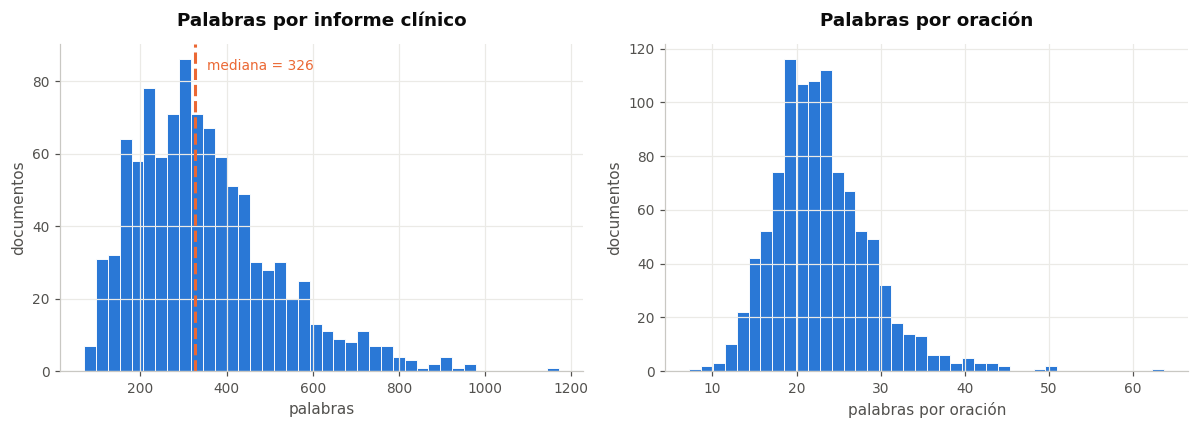


Un chiste del notebook guia tiene ~31 palabras (mediana).
Un informe clinico de SPACCC tiene 326 palabras (mediana), 11 veces mas.


In [59]:
# PASO 04.1 - Longitudes en caracteres y palabras
eda = pd.DataFrame({'doc_id': list(textos), 'texto': [textos[k] for k in textos]})
eda['particion'] = np.where(eda.doc_id.isin(ids_train), 'train', 'test')
eda['caracteres'] = eda.texto.str.len()
eda['palabras'] = eda.texto.str.split().map(len)
eda['oraciones'] = eda.texto.map(lambda t: max(1, len(re.findall(r'[.!?]+\s', t))))
eda['palabras_por_oracion'] = eda.palabras / eda.oraciones

print(eda[['caracteres', 'palabras', 'oraciones', 'palabras_por_oracion']].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(eda.palabras, bins=40, color=SERIE[0], edgecolor='white', linewidth=0.6)
axes[0].axvline(eda.palabras.median(), color=SERIE[1], linewidth=2, linestyle='--')
axes[0].annotate(f'mediana = {eda.palabras.median():.0f}',
                 (eda.palabras.median(), axes[0].get_ylim()[1] * 0.92),
                 xytext=(8, 0), textcoords='offset points', color=SERIE[1], fontsize=9)
axes[0].set_title('Palabras por informe clínico')
axes[0].set_xlabel('palabras'); axes[0].set_ylabel('documentos')

axes[1].hist(eda.palabras_por_oracion, bins=40, color=SERIE[0], edgecolor='white', linewidth=0.6)
axes[1].set_title('Palabras por oración')
axes[1].set_xlabel('palabras por oración'); axes[1].set_ylabel('documentos')
guardar('eda_longitudes')

print(f"\nUn chiste del notebook guia tiene ~31 palabras (mediana).")
print(f"Un informe clinico de SPACCC tiene {eda.palabras.median():.0f} palabras (mediana), "
      f"{eda.palabras.median()/31:.0f} veces mas.")

**Hallazgo 1 — el cambio de escala obliga a cambiar la preparación de los datos.**
Un chiste del notebook guía tiene unas 31 palabras de mediana, así que truncar a 64 tokens casi no
pierde nada: el chiste entero entra. Un informe clínico de SPACCC es **un orden de magnitud más
largo**. Si copiáramos el `truncation=True, max_length=64` del notebook guía estaríamos tirando a
la basura más del 90 % del corpus, y además entrenaríamos al modelo **solo con los comienzos** de
los informes — es decir, con la fórmula demográfica de apertura repetida mil veces y nada del
cuerpo clínico.

Esta es la primera razón por la que en el PASO 06 **concatenamos y troceamos** en lugar de truncar.

### 4.2 El vocabulario: ley de Zipf y cola larga

Un modelo de lenguaje es una distribución sobre tokens. Si el corpus tiene una cola muy larga de
términos rarísimos, el modelo tiene poco de dónde aprenderlos. Medimos cuántas palabras aparecen
una sola vez (*hapax legomena*) y verificamos la ley de Zipf.

{
  "tokens_palabra_totales": 342932,
  "vocabulario_unico": 21422,
  "hapax_legomena": 9409,
  "porcentaje_hapax": 43.922136121744,
  "razon_tipo_token": 0.062467194662498685
}

15 palabras mas frecuentes: ['de', 'la', 'y', 'en', 'se', 'el', 'con', 'a', 'una', 'que', 'del', 'un', 'por', 'los', 'paciente']
15 hapax de ejemplo: ['pecho', 'tifoidea', 'ipss', 'firboelástica', 'induraciones', 'demoró', 'visualizaban', 'neuroectodérmico', 'inmunohisoquímica', 'presacro', 'iiiea', 'ipi', 'flipi', 'poliquimioterápia', 'linea']


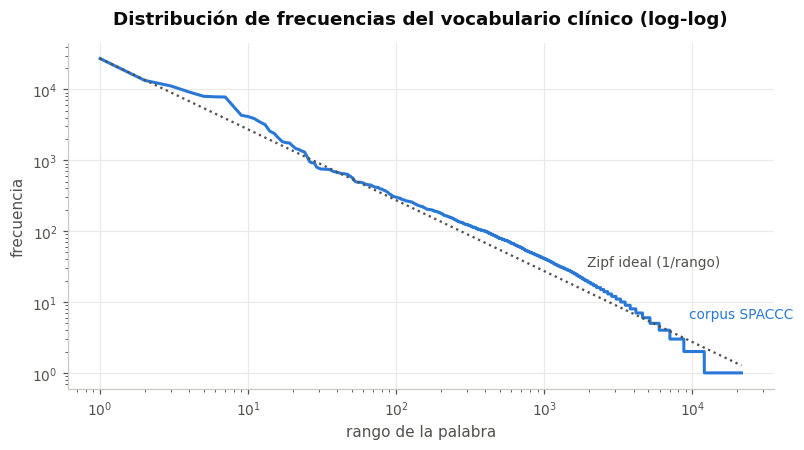

In [60]:
# PASO 04.2 - Vocabulario, hapax y ley de Zipf
palabras_todas = re.findall(r"[a-záéíóúñü]+", ' '.join(textos.values()).lower())
frecuencias = Counter(palabras_todas)
ordenadas = frecuencias.most_common()
hapax = sum(1 for _, c in ordenadas if c == 1)

vocab_info = {
    'tokens_palabra_totales': len(palabras_todas),
    'vocabulario_unico': len(frecuencias),
    'hapax_legomena': hapax,
    'porcentaje_hapax': 100 * hapax / len(frecuencias),
    'razon_tipo_token': len(frecuencias) / len(palabras_todas),
}
print(json.dumps(vocab_info, indent=2))
print('\n15 palabras mas frecuentes:', [p for p, _ in ordenadas[:15]])
print('15 hapax de ejemplo:', [p for p, c in ordenadas if c == 1][:15])

rangos = np.arange(1, len(ordenadas) + 1)
conteos = np.array([c for _, c in ordenadas])
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.loglog(rangos, conteos, color=SERIE[0], linewidth=2)
# Referencia Zipf ideal: frecuencia proporcional a 1/rango, anclada en la palabra mas frecuente.
ax.loglog(rangos, conteos[0] / rangos, color=TINTA_SUAVE, linewidth=1.5, linestyle=':')
ax.annotate('Zipf ideal (1/rango)', (rangos[len(rangos)//14], conteos[0] / rangos[len(rangos)//14]),
            xytext=(10, 12), textcoords='offset points', color=TINTA_SUAVE, fontsize=9)
ax.annotate('corpus SPACCC', (rangos[len(rangos)//3], conteos[len(rangos)//3]),
            xytext=(12, 14), textcoords='offset points', color=SERIE[0], fontsize=9)
ax.set_title('Distribución de frecuencias del vocabulario clínico (log-log)')
ax.set_xlabel('rango de la palabra'); ax.set_ylabel('frecuencia')
guardar('eda_zipf')

**Hallazgo 2 — la terminología clínica vive casi toda en la cola.**
La curva sigue a Zipf en su tramo central, pero lo relevante es la proporción de *hapax legomena*:
una fracción muy alta del vocabulario aparece **una sola vez** en todo el corpus. Y al mirar los
ejemplos se ve que no son erratas, son los términos verdaderamente específicos
(nombres de fármacos, procedimientos, hallazgos histológicos).

Consecuencia directa para nuestro experimento: **el fine-tuning no puede "aprender" ese vocabulario
de cola** con 750 documentos. Lo que sí puede aprender es la *estructura*, el *registro* y las
*coocurrencias frecuentes*. Esta es una expectativa que fijamos **antes** de ver los resultados, y
que contrastaremos en las conclusiones — es la diferencia entre analizar y contar anécdotas.

### 4.3 Estructura retórica y demografía

Extraemos con expresiones regulares la edad y el sexo declarados en la apertura de cada informe, y
medimos qué tan frecuentes son las fórmulas de apertura y las secciones típicas. Esto nos dice
**qué patrón concreto debería reproducir el modelo si el fine-tuning funciona**, y de aquí salen
los *prompts* de evaluación.

Edad declarada en 91.9% de los informes; mediana 47 anos.
sexo
varón           484
mujer           316
no declarado    200

Apertura con la formula demografica en los primeros 120 caracteres:
  81.0% de los 1000 informes


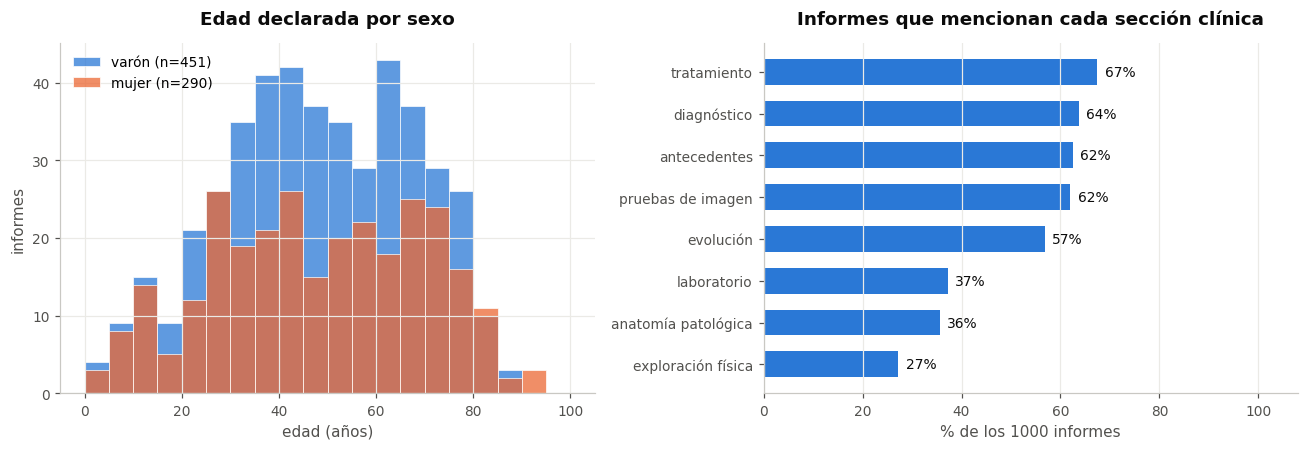

In [61]:
# PASO 04.3 - Demografia declarada y estructura retorica
PATRON_EDAD = re.compile(r'\b(\d{1,3})\s*a(?:n|ñ)os\b', re.IGNORECASE)
PATRON_VARON = re.compile(r'\b(var[oó]n|hombre|ni[nñ]o|paciente\s+masculino)\b', re.IGNORECASE)
PATRON_MUJER = re.compile(r'\b(mujer|ni[nñ]a|paciente\s+femenina)\b', re.IGNORECASE)

def edad_declarada(texto, ventana=300):
    """Primera edad en anos mencionada en la apertura del informe (None si no aparece)."""
    encontrado = PATRON_EDAD.search(texto[:ventana])
    if not encontrado:
        return None
    edad = int(encontrado.group(1))
    return edad if 0 < edad <= 110 else None

def sexo_declarado(texto, ventana=300):
    inicio = texto[:ventana]
    v, m = PATRON_VARON.search(inicio), PATRON_MUJER.search(inicio)
    if v and m:
        return 'varón' if v.start() < m.start() else 'mujer'
    if v:
        return 'varón'
    if m:
        return 'mujer'
    return 'no declarado'

eda['edad'] = eda.texto.map(edad_declarada)
eda['sexo'] = eda.texto.map(sexo_declarado)

SECCIONES = {
    'antecedentes': r'antecedente',
    'exploración física': r'exploraci[oó]n f[ií]sica',
    'pruebas de imagen': r'\b(ecograf[ií]a|radiograf[ií]a|TAC|tomograf[ií]a|resonancia)\b',
    'laboratorio': r'\b(anal[ií]tica|hemograma|bioqu[ií]mica|creatinina|hemoglobina)\b',
    'anatomía patológica': r'\b(biopsia|anatom[ií]a patol[oó]gica|histol[oó]g)',
    'tratamiento': r'\b(tratamiento|se instaur|se pauta|terapia)\b',
    'evolución': r'\b(evoluci[oó]n|seguimiento|control a los)\b',
    'diagnóstico': r'\bdiagn[oó]stic',
}
cobertura = {nombre: 100 * eda.texto.str.contains(patron, case=False, regex=True).mean()
             for nombre, patron in SECCIONES.items()}

print('Edad declarada en %.1f%% de los informes; mediana %.0f anos.'
      % (100 * eda.edad.notna().mean(), eda.edad.median()))
print(eda.sexo.value_counts().to_string())
print('\nApertura con la formula demografica en los primeros 120 caracteres:')
apertura = eda.texto.str[:120].str.contains(
    r'^(?:se trata de\s+)?(?:un|una)?\s*(?:var[oó]n|mujer|paciente|ni[nñ]o|ni[nñ]a)', case=False, regex=True)
print(f'  {100 * apertura.mean():.1f}% de los 1000 informes')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sub = eda[eda.edad.notna()]
for i, (nombre, grupo) in enumerate([(s, sub[sub.sexo == s]) for s in ['varón', 'mujer']]):
    axes[0].hist(grupo.edad, bins=range(0, 105, 5), alpha=0.75, color=SERIE[i],
                 label=f'{nombre} (n={len(grupo)})', edgecolor='white', linewidth=0.6)
axes[0].legend(loc='upper left')
axes[0].set_title('Edad declarada por sexo')
axes[0].set_xlabel('edad (años)'); axes[0].set_ylabel('informes')

orden = sorted(cobertura.items(), key=lambda kv: kv[1])
axes[1].barh([k for k, _ in orden], [v for _, v in orden], color=SERIE[0], height=0.62)
for y, (_, v) in enumerate(orden):
    axes[1].annotate(f'{v:.0f}%', (v, y), xytext=(5, 0), textcoords='offset points',
                     va='center', fontsize=9, color=TINTA)
axes[1].set_xlim(0, 108)
axes[1].set_title('Informes que mencionan cada sección clínica')
axes[1].set_xlabel('% de los 1000 informes')
axes[1].grid(axis='y', visible=False)
guardar('eda_estructura')

**Hallazgo 3 — hay un guion, y es muy estable.**
La gran mayoría de los informes abre con la fórmula demográfica (*"Varón de N años..."*,
*"Se trata de una paciente de N años..."*) y menciona antecedentes, pruebas y tratamiento en un
orden reconocible. La distribución de edades está desplazada hacia la vida adulta y madura, con
presencia clara de ambos sexos.

Esto es exactamente lo que un modelo causal **puede** capturar con pocos datos, porque es
estructura de alta frecuencia y no vocabulario de cola. Por eso los *prompts* de evaluación del
`CFG` imitan esa apertura: le damos al modelo el comienzo del patrón y observamos si continúa por
el guion clínico o si se va hacia el español general con el que fue preentrenado.

### 4.4 Terminología clínica presente (usando las anotaciones)

Aprovechamos las 44 996 anotaciones de entidades del corpus NER para caracterizar **qué tipo de
contenido clínico** tiene que modelar el generador. No entrenamos con ellas; son una lente sobre
el dominio.

Anotaciones por categoria:
label
PROCEDURE    14683
SYMPTOM      12193
DISEASE      10663
CHEMICAL      4448
PROTEIN       3009

Entidades clinicas por informe: mediana 40, media 45.0, maximo 183


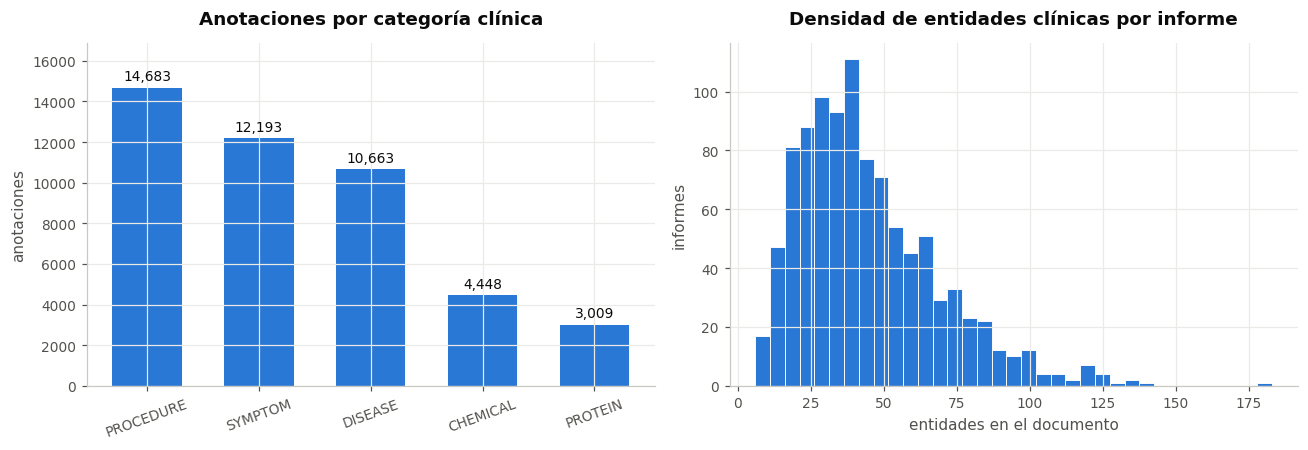


Terminos clinicos mas repetidos en el corpus (literal de la anotacion):
text
exploración física       280
lesión                   238
fiebre                   210
analítica                183
exploración              182
creatinina               168
dolor                    167
cirugía                  164
tac                      148
intervención             135
corticoides              129
hemograma                117
tc                       116
asintomático             115
radiografía de tórax     112
hemoglobina              111
lesiones                  99
ecografía abdominal       99
hipertensión arterial     91
ecografía                 90


In [62]:
# PASO 04.4 - Que terminologia clinica contiene el corpus
anot = pd.concat([df_anotaciones, df_anotaciones_test], ignore_index=True)
print('Anotaciones por categoria:')
print(anot.label.value_counts().to_string())

entidades_por_doc = anot.groupby('doc_id').size()
print(f'\nEntidades clinicas por informe: mediana {entidades_por_doc.median():.0f}, '
      f'media {entidades_por_doc.mean():.1f}, maximo {entidades_por_doc.max()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
conteo = anot.label.value_counts()
axes[0].bar(conteo.index, conteo.values, color=SERIE[0], width=0.62)
etiquetar_barras(axes[0], '{:,.0f}')
axes[0].set_title('Anotaciones por categoría clínica')
axes[0].set_ylabel('anotaciones'); axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, conteo.max() * 1.15)

axes[1].hist(entidades_por_doc, bins=35, color=SERIE[0], edgecolor='white', linewidth=0.6)
axes[1].set_title('Densidad de entidades clínicas por informe')
axes[1].set_xlabel('entidades en el documento'); axes[1].set_ylabel('informes')
guardar('eda_entidades')

print('\nTerminos clinicos mas repetidos en el corpus (literal de la anotacion):')
print(anot.text.str.lower().value_counts().head(20).to_string())

### 4.5 Fertilidad de los tokenizadores: la medida clave del taller

Aquí está el análisis que más nos alejó del notebook guía. Un tokenizador BPE preentrenado en
español general **no conoce** las palabras clínicas, así que las parte en muchos subtokens. Llamamos
**fertilidad** al número medio de subtokens por palabra. Una fertilidad alta significa tres cosas:

1. El modelo gasta más pasos de predicción para decir lo mismo.
2. El texto clínico "pesa" más en tokens, así que caben menos palabras por bloque.
3. **Su perplejidad por token no es comparable con la de otro modelo** que parta el texto en un
   número distinto de piezas — una perplejidad baja puede venir de tokens más cortos y fáciles, no
   de un mejor modelo.

Ese tercer punto es el que nos obliga a introducir los **bits por carácter** en el PASO 08.
Medimos la fertilidad de los dos candidatos sobre texto clínico y sobre texto general, para que la
comparación tenga un control.

          checkpoint dominio  vocabulario  subtokens_por_palabra  caracteres_por_subtoken
mrm8488/spanish-gpt2 clínico        50265                  1.528                    4.457
mrm8488/spanish-gpt2 general        50265                  1.085                    5.294
DeepESP/gpt2-spanish clínico        50257                  1.555                    4.381
DeepESP/gpt2-spanish general        50257                  1.106                    5.192


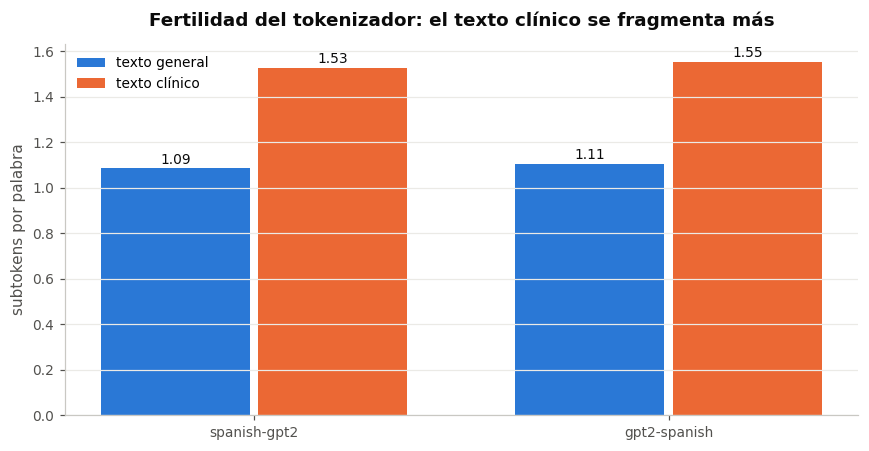


Ejemplo de fragmentacion de terminos clinicos:

  mrm8488/spanish-gpt2
    adenocarcinoma         -> 5 piezas: ['Ġaden', 'o', 'car', 'cin', 'oma']
    hipertrofia            -> 3 piezas: ['Ġhiper', 'tro', 'fia']
    inmunohistoquimica     -> 5 piezas: ['Ġinmuno', 'h', 'isto', 'qui', 'mica']
    corticoides            -> 3 piezas: ['Ġcor', 'tico', 'ides']
    hemoglobina            -> 1 piezas: ['Ġhemoglobina']

  DeepESP/gpt2-spanish
    adenocarcinoma         -> 5 piezas: ['Ġaden', 'o', 'car', 'cin', 'oma']
    hipertrofia            -> 3 piezas: ['Ġhiper', 'tro', 'fia']
    inmunohistoquimica     -> 6 piezas: ['Ġinm', 'uno', 'h', 'isto', 'quim', 'ica']
    corticoides            -> 3 piezas: ['Ġcor', 'tico', 'ides']
    hemoglobina            -> 3 piezas: ['Ġhemo', 'glob', 'ina']


In [63]:
# PASO 04.5 - Fertilidad comparada de los tokenizadores
from transformers import AutoTokenizer

TEXTO_GENERAL = (
    'El domingo por la tarde fuimos al parque con los niños y compramos helado en la esquina. '
    'La semana pasada llovió mucho y tuvimos que quedarnos en casa viendo películas antiguas. '
    'Mi hermano estudia ingeniería en la universidad y trabaja los fines de semana en una tienda.'
)
muestra_clinica = ' '.join(textos[k] for k in ids_train[:40])

candidatos = [CFG['checkpoint_principal'], CFG['checkpoint_alternativo']]
tokenizadores = {}
filas_fert = []
for nombre in candidatos:
    tok = AutoTokenizer.from_pretrained(nombre)
    if tok.pad_token is None:
        # Los GPT-2 no traen token de relleno; reutilizamos el de fin de secuencia.
        tok.pad_token = tok.eos_token
    tokenizadores[nombre] = tok
    for dominio, texto in [('clínico', muestra_clinica), ('general', TEXTO_GENERAL)]:
        n_palabras = len(texto.split())
        n_subtokens = len(tok(texto, add_special_tokens=False)['input_ids'])
        filas_fert.append({'checkpoint': nombre, 'dominio': dominio,
                           'vocabulario': tok.vocab_size,
                           'subtokens_por_palabra': n_subtokens / n_palabras,
                           'caracteres_por_subtoken': len(texto) / n_subtokens})
fertilidad = pd.DataFrame(filas_fert)
print(fertilidad.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.2))
etiquetas = candidatos
x = np.arange(len(etiquetas)); ancho = 0.36
for i, dominio in enumerate(['general', 'clínico']):
    valores = [fertilidad[(fertilidad.checkpoint == c) & (fertilidad.dominio == dominio)]
               .subtokens_por_palabra.iloc[0] for c in etiquetas]
    barras = ax.bar(x + (i - 0.5) * (ancho + 0.02), valores, ancho, color=SERIE[i],
                    label=f'texto {dominio}')
    for barra in barras:
        ax.annotate(f'{barra.get_height():.2f}', (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9, color=TINTA)
ax.set_xticks(x); ax.set_xticklabels([c.split('/')[-1] for c in etiquetas])
ax.set_ylabel('subtokens por palabra'); ax.legend()
ax.set_title('Fertilidad del tokenizador: el texto clínico se fragmenta más')
ax.grid(axis='x', visible=False)
guardar('eda_fertilidad')

print('\nEjemplo de fragmentacion de terminos clinicos:')
terminos = ['adenocarcinoma', 'hipertrofia', 'inmunohistoquimica', 'corticoides', 'hemoglobina']
for nombre, tok in tokenizadores.items():
    print(f'\n  {nombre}')
    for termino in terminos:
        piezas = tok.tokenize(' ' + termino)
        print(f'    {termino:22s} -> {len(piezas)} piezas: {piezas}')
REPORTE['fertilidad'] = fertilidad.to_dict('records')

**Hallazgo 4 — el texto clínico se fragmenta más que el texto general, en los dos tokenizadores.**
La fertilidad sube al pasar de español general a español clínico: los mismos modelos necesitan más
subtokens por palabra para escribir lo mismo. Y al mirar la fragmentación término a término se ve
el mecanismo: palabras como `inmunohistoquímica` se descomponen en varias piezas sin significado
clínico propio.

Dos consecuencias que arrastramos al resto del notebook:

- Con `block_size=256` cabe **menos contenido clínico** del que cabría de texto general. Lo
  asumimos a cambio de poder entrenar rápido; queda anotado como limitación.
- Los dos checkpoints **no fragmentan igual**, así que en el PASO 12 los compararemos en bits por
  carácter, no en perplejidad. Si compartiéramos la perplejidad estaríamos comparando peras con
  manzanas y el error pasaría inadvertido.

## PASO 05 — Partición sin fuga

Usamos la partición **oficial** del corpus, por documento:

- **750 documentos de train** → con ellos se hace el fine-tuning.
- **250 documentos de test** → reservados. Solo se usan para medir perplejidad y bits por carácter.

Esto es distinto de lo que hace el notebook guía, que aplica `train_test_split(0.9)` sobre el
dataset ya tokenizado. Ese enfoque tiene dos problemas para nuestro caso: parte **bloques** en vez
de documentos (dos trozos del mismo informe pueden caer uno en train y otro en test, que es fuga), y
no fija semilla, así que la partición cambia en cada ejecución.

Del train oficial apartamos además un 10 % de documentos como **validación** para la parada del
entrenamiento, sin tocar nunca el test.

In [64]:
# PASO 05 - Particion por documento, sin fuga
generador = np.random.default_rng(CFG['semilla'])
orden = generador.permutation(ids_train).tolist()
n_val = max(1, round(0.10 * len(orden)))
ids_validacion = sorted(orden[:n_val])
ids_entrenamiento = sorted(orden[n_val:])

assert not set(ids_entrenamiento) & set(ids_validacion)
assert not (set(ids_entrenamiento) | set(ids_validacion)) & set(ids_test)

if CFG['prueba_rapida']:
    ids_entrenamiento = ids_entrenamiento[:60]
    ids_validacion = ids_validacion[:10]
    ids_evaluacion = ids_test[:20]
else:
    ids_evaluacion = ids_test

REPORTE['particion'] = {
    'entrenamiento': len(ids_entrenamiento), 'validacion': len(ids_validacion),
    'test_reservado': len(ids_evaluacion),
    'sha256': hashlib.sha256(json.dumps(
        {'tr': ids_entrenamiento, 'va': ids_validacion, 'te': ids_evaluacion}, sort_keys=True).encode()).hexdigest(),
}
print('PASO 05 OK:', json.dumps(REPORTE['particion'], indent=2))

PASO 05 OK: {
  "entrenamiento": 675,
  "validacion": 75,
  "test_reservado": 250,
  "sha256": "ddca7028a67ee6ae56ea8ee52e9ab171bd92862e2755c8160d44171615a0a070"
}


## PASO 06 — Preparación: concatenar y trocear, no truncar

Esta es la corrección metodológica central respecto al notebook guía.

- **Lo que hace el guía**: `tokenizer(texto, max_length=64, truncation=True)`. Cada ejemplo produce
  un bloque de como máximo 64 tokens y **el resto del texto se descarta**.
- **Lo que hacemos aquí**: tokenizamos cada documento completo, **concatenamos** todos los tokens en
  una única secuencia (separando documentos con el token de fin de secuencia) y la **cortamos en
  bloques contiguos** de `block_size`. No se descarta nada salvo el resto final, menor que un bloque.

La consecuencia práctica se ve en el conteo de bloques que imprime la celda: pasamos de 750 bloques
truncados a varios miles de bloques que cubren el corpus entero.

El token de fin de secuencia entre documentos importa: sin él, el modelo aprendería transiciones
inexistentes entre el final de un informe y el comienzo del siguiente.

In [65]:
# PASO 06 - Tokenizacion, concatenacion y troceado en bloques
from datasets import Dataset, DatasetDict

def preparar_bloques(tokenizador, doc_ids, block_size, descripcion=''):
    """Tokeniza los documentos `doc_ids`, los concatena separandolos con el token de fin de
    secuencia y devuelve la lista de bloques contiguos de exactamente `block_size` tokens.

    Devuelve (bloques, estadisticas). A diferencia de truncar, aprovecha todo el texto: solo se
    descarta el resto final, que por construccion mide menos de un bloque."""
    eos = tokenizador.eos_token_id
    corriente = []
    for doc_id in doc_ids:
        corriente.extend(tokenizador(textos[doc_id], add_special_tokens=False)['input_ids'])
        corriente.append(eos)
    total = (len(corriente) // block_size) * block_size
    bloques = [corriente[i:i + block_size] for i in range(0, total, block_size)]
    estadisticas = {
        'documentos': len(doc_ids), 'tokens_totales': len(corriente), 'bloques': len(bloques),
        'tokens_descartados': len(corriente) - total,
        'tokens_por_documento': len(corriente) / len(doc_ids),
        'bloques_si_truncaramos_a_64': len(doc_ids),
    }
    if descripcion:
        print(f'  {descripcion}: {estadisticas["bloques"]} bloques de {block_size} tokens '
              f'({estadisticas["tokens_totales"]:,} tokens, '
              f'{estadisticas["tokens_por_documento"]:.0f} por documento)')
    return bloques, estadisticas

tokenizador = tokenizadores[CFG['checkpoint_principal']]
print(f'Preparando bloques con {CFG["checkpoint_principal"]}:')
bloques_train, est_train = preparar_bloques(tokenizador, ids_entrenamiento, CFG['block_size'], 'entrenamiento')
bloques_val, est_val = preparar_bloques(tokenizador, ids_validacion, CFG['block_size'], 'validación')
bloques_test, est_test = preparar_bloques(tokenizador, ids_evaluacion, CFG['block_size'], 'test reservado')

datos = DatasetDict({
    'train': Dataset.from_dict({'input_ids': bloques_train}),
    'validation': Dataset.from_dict({'input_ids': bloques_val}),
})
datos.set_format('torch')

REPORTE['bloques'] = {'train': est_train, 'validation': est_val, 'test': est_test}
print()
print(f'Con truncado a 64 tokens (enfoque del notebook guia) tendriamos {est_train["documentos"]} '
      f'bloques y perderiamos texto.')
print(f'Con concatenado y troceado tenemos {est_train["bloques"]} bloques y no perdemos nada: '
      f'{est_train["bloques"] / est_train["documentos"]:.1f} veces mas material de entrenamiento.')
print(datos)

Preparando bloques con mrm8488/spanish-gpt2:
  entrenamiento: 1425 bloques de 256 tokens (364,838 tokens, 541 por documento)
  validación: 155 bloques de 256 tokens (39,818 tokens, 531 por documento)
  test reservado: 527 bloques de 256 tokens (134,973 tokens, 540 por documento)

Con truncado a 64 tokens (enfoque del notebook guia) tendriamos 675 bloques y perderiamos texto.
Con concatenado y troceado tenemos 1425 bloques y no perdemos nada: 2.1 veces mas material de entrenamiento.
DatasetDict({
    train: Dataset({
        features: ['input_ids'],
        num_rows: 1425
    })
    validation: Dataset({
        features: ['input_ids'],
        num_rows: 155
    })
})


## PASO 07 — El modelo base antes de tocarlo

Cargamos el GPT-2 español preentrenado y observamos qué genera **sin ningún ajuste**, con nuestros
*prompts* clínicos. Este es el punto de partida cualitativo: si el fine-tuning sirve de algo,
tendrá que notarse contra esto.

Detalle técnico importante: los GPT-2 no traen token de relleno. Reutilizamos el token de fin de
secuencia como relleno y se lo declaramos también al modelo. **No** llamamos a
`resize_token_embeddings`, porque no añadimos tokens nuevos al vocabulario: hacerlo añadiría filas
inicializadas al azar en la matriz de *embeddings* sin ninguna necesidad.

In [66]:
# PASO 07 - Carga del modelo base y generacion sin ajustar
# set_seed se importa aqui, no en la celda de entrenamiento, para que las celdas de
# generacion (PASO 11 y 14) no dependan de haber ejecutado el PASO 09.
from transformers import AutoModelForCausalLM, set_seed

def cargar_modelo(nombre, tokenizador):
    """Carga un GPT-2 causal y alinea su configuracion con el token de relleno del tokenizador.

    Comprueba que el tokenizador no tenga mas tokens que filas la matriz de embeddings. Si los
    tuviera, cualquier id por encima del rango provocaria un `device-side assert` dentro de la
    GPU: un error asincrono que envenena el contexto de CUDA y obliga a reiniciar el kernel,
    apareciendo despues en lineas que no tienen nada que ver. Redimensionamos solo si hace falta
    (el notebook guia lo hace siempre, lo que anade filas al azar sin necesidad)."""
    modelo = AutoModelForCausalLM.from_pretrained(nombre)
    # Algunos checkpoints se publican con los pesos en float16 y las versiones recientes de
    # transformers respetan ese dtype al cargar. Entrenar con fp16 de AMP exige pesos maestros
    # en float32: el GradScaler no puede desescalar gradientes que ya son fp16 y falla con
    # 'Attempting to unscale FP16 gradients'. Por eso normalizamos a float32 siempre.
    dtype_original = next(modelo.parameters()).dtype
    if dtype_original != torch.float32:
        print(f'AVISO: {nombre} viene en {dtype_original}; convirtiendo a float32 para poder '
              'entrenar con precision mixta.')
        modelo = modelo.float()
    modelo = modelo.to(device)
    modelo.config.pad_token_id = tokenizador.pad_token_id
    filas = modelo.get_input_embeddings().weight.shape[0]
    if len(tokenizador) > filas:
        print(f'AVISO: el tokenizador tiene {len(tokenizador)} tokens y el modelo {filas} filas '
              f'de embedding; redimensionando para evitar indices fuera de rango.')
        modelo.resize_token_embeddings(len(tokenizador))
    return modelo

def verificar_ids(bloques, modelo, etiqueta=''):
    """Falla en Python -antes de tocar la GPU- si algun id de token excede el vocabulario del
    modelo. Sin esta comprobacion el sintoma seria un `device-side assert` imposible de localizar."""
    filas = modelo.get_input_embeddings().weight.shape[0]
    maximo = max(max(bloque) for bloque in bloques)
    assert 0 <= maximo < filas, (
        f'{etiqueta}: hay un id de token ({maximo}) fuera del vocabulario del modelo ({filas} filas). '
        'Casi siempre significa que los bloques se tokenizaron con un tokenizador distinto al del '
        'modelo: vuelve a ejecutar el PASO 06 despues de cambiar el checkpoint.')
    return maximo

modelo_base = cargar_modelo(CFG['checkpoint_principal'], tokenizador)
n_parametros = sum(p.numel() for p in modelo_base.parameters())
print(f'{CFG["checkpoint_principal"]}: {n_parametros:,} parametros, '
      f'{modelo_base.config.n_layer} capas, {modelo_base.config.n_head} cabezas, '
      f'contexto maximo {modelo_base.config.n_positions}')
print('Tipo de modelo:', type(modelo_base).__name__)

# Barrera de seguridad: los bloques del PASO 06 deben pertenecer a ESTE modelo.
for etiqueta, bloques in [('train', bloques_train), ('validation', bloques_val), ('test', bloques_test)]:
    maximo = verificar_ids(bloques, modelo_base, etiqueta)
print(f'Ids de token dentro del rango del modelo (maximo observado {maximo}, '
      f'{modelo_base.get_input_embeddings().weight.shape[0]} filas de embedding). '
      'Tokenizador y modelo son consistentes.')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AVISO: el tokenizador tiene 50266 tokens y el modelo 50257 filas de embedding; redimensionando para evitar indices fuera de rango.
mrm8488/spanish-gpt2: 124,446,720 parametros, 12 capas, 12 cabezas, contexto maximo 1024
Tipo de modelo: GPT2LMHeadModel
Ids de token dentro del rango del modelo (maximo observado 50265, 50266 filas de embedding). Tokenizador y modelo son consistentes.


### 7.1 Una función de generación propia, con `top_p` añadido

Partimos de la función `generate` del notebook guía, que implementa una política **e-greedy** entre
tomar el token más probable y muestrear. Le añadimos **núcleo (`top_p`)**, que es la técnica de
decodificación que se usa hoy en la práctica y que el notebook guía no cubre: en vez de fijar un
número de candidatos, se queda con el conjunto más pequeño de tokens cuya probabilidad acumulada
supera `p`. Así el número de candidatos se adapta a cada paso — es amplio cuando el modelo está
indeciso y estrecho cuando está seguro.

Devolvemos también la traza paso a paso para poder **inspeccionar la distribución** en cada
posición, que es lo que hace didáctica a esta implementación manual frente a `model.generate`.

In [67]:
# PASO 07.1 - Generacion manual e-greedy con nucleo top_p (adaptada del notebook guia)
from typing import Optional, Tuple

@torch.no_grad()
def generar_manual(modelo, tokenizador, inicio: str, max_length: int = 100,
                   eps: float = 0.5, top_n: int = 5, top_p: Optional[float] = None,
                   temperatura: float = 1.0, devolver_traza: bool = False,
                   dispositivo: str = 'cpu') -> Tuple[str, Optional[pd.DataFrame]]:
    """Genera texto token a token con una politica e-greedy, opcionalmente restringida a un
    nucleo top_p.

    eps=1 -> siempre el token mas probable (greedy, deterministico).
    eps=0 -> siempre muestreo segun la distribucion.
    0<eps<1 -> mezcla binomial entre ambas.
    top_p -> antes de muestrear, se descarta la cola: se conserva el conjunto minimo de tokens
             cuya probabilidad acumulada alcanza p. Es la aportacion propia sobre la version guia.
    """
    modelo.eval()
    texto = inicio
    traza = []
    input_ids = tokenizador(texto, return_tensors='pt')['input_ids'].to(dispositivo)
    for paso in range(max_length):
        logits = modelo(input_ids=input_ids).logits[0, -1, :] / max(temperatura, 1e-6)
        probs = torch.softmax(logits, dim=-1)
        ordenados = torch.argsort(probs, dim=-1, descending=True)

        candidatos = ordenados
        if top_p is not None:
            acumulada = torch.cumsum(probs[ordenados], dim=-1)
            # Numero minimo de tokens cuya probabilidad acumulada alcanza p (al menos uno).
            corte = int((acumulada < top_p).sum().item()) + 1
            candidatos = ordenados[:min(max(1, corte), ordenados.numel())]

        if np.random.random_sample() < eps:
            siguiente = candidatos[0].unsqueeze(0)
        else:
            masa = probs[candidatos]
            masa = masa / masa.sum()
            elegido = torch.multinomial(masa, num_samples=1)
            siguiente = candidatos[elegido].reshape(1)

        if devolver_traza:
            traza.append({'paso': paso, 'contexto_final': tokenizador.decode(input_ids[0, -6:]),
                          'elegido': tokenizador.decode(siguiente),
                          'p_elegido': float(probs[siguiente].item()),
                          'candidatos_en_nucleo': int(len(candidatos)),
                          'top_n': {tokenizador.decode(t): round(float(probs[t]), 4)
                                    for t in ordenados[:top_n]}})
        input_ids = torch.cat([input_ids, siguiente.unsqueeze(0)], dim=-1)
        if siguiente.item() == tokenizador.eos_token_id:
            break
        # Cortamos el contexto si nos acercamos al maximo posicional del modelo.
        if input_ids.shape[-1] >= modelo.config.n_positions:
            input_ids = input_ids[:, -modelo.config.n_positions + 1:]
    texto = tokenizador.decode(input_ids[0], skip_special_tokens=True)
    return texto, (pd.DataFrame(traza) if devolver_traza else None)

prompt_demo = CFG['prompts'][0]
texto_base, traza = generar_manual(modelo_base, tokenizador, prompt_demo, max_length=12,
                                   eps=1.0, top_n=5, devolver_traza=True, dispositivo=device)
print('--- Generacion greedy (eps=1) con el modelo BASE ---')
print(texto_base)
print('\nTraza de decision paso a paso:')
display(traza[['paso', 'elegido', 'p_elegido', 'top_n']])

--- Generacion greedy (eps=1) con el modelo BASE ---
Varón de 54 años con antecedentes de hipertensión arterial.- ¿Qué?- ¿Qué?- ¿Qué

Traza de decision paso a paso:


,paso,elegido,p_elegido,top_n
0,0,.,0.327273,"{'.': 0.3273, ',': 0.1619, ' y': 0.1335, ' pul..."
1,1,-,0.080950,"{'-': 0.081, '¿': 0.051, 'La': 0.0401, 'El': 0..."
2,2,¿,0.385134,"{' ¿': 0.3851, ' ¡': 0.0306, ' No': 0.0236, ' ..."
3,3,Qué,0.132729,"{'Qué': 0.1327, 'Y': 0.041, 'Cómo': 0.0365, 'D..."
4,4,?,0.121205,"{'?': 0.1212, ' es': 0.08, ' le': 0.0504, ' ha..."
5,5,-,0.867472,"{'-': 0.8675, '¿': 0.0817, 'No': 0.0074, '¡': ..."
6,6,¿,0.141413,"{' ¿': 0.1414, ' No': 0.0447, ' Es': 0.0343, '..."
7,7,Qué,0.260643,"{'Qué': 0.2606, 'Cómo': 0.0395, 'Dónde': 0.031..."
8,8,?,0.654319,"{'?': 0.6543, ' pasa': 0.0356, ' es': 0.0343, ..."
9,9,-,0.242299,"{'-': 0.2423, '¿': 0.2006, 'No': 0.0489, '¡': ..."


In [68]:
# PASO 07.2 - Como escribe el modelo BASE sobre prompts clinicos (muestreo con nucleo)
generaciones_base = {}
for prompt in CFG['prompts']:
    salida, _ = generar_manual(modelo_base, tokenizador, prompt, max_length=CFG['max_new_tokens'],
                               eps=0.2, top_p=0.92, temperatura=0.9, dispositivo=device)
    generaciones_base[prompt] = salida
    print('=' * 100)
    print('PROMPT:', prompt)
    print(salida)
REPORTE['generaciones_base'] = generaciones_base

PROMPT: Varón de 54 años con antecedentes de hipertensión arterial
Varón de 54 años con antecedentes de hipertensión arterial alta (hipertensión)-Diagnóstico de hipertensión de alto estándar-Diagnóstico de hipertensión de bajo estándar-Diagnóstico de hipertensión de alto estándar-Diagnóstico de hipertensión de alto estándar-Hipertensión de alto estándar-Hipertensión de bajo estándar-Hipertensión de alto estándar-Hipertensión de alto estándar-Hipertensión de alto estándarHipertensión de alto estándarHipertensión de alto estándarHipertensión de alto estándarHipertensión de alto estándarHipertensión de alto estándarHipertensión de alto estándarHipertensión de bajo estándarHipertensión de alto estándar
PROMPT: Mujer de 32 años que acude a urgencias por dolor abdominal
Mujer de 32 años que acude a urgencias por dolor abdominal.Ella también sufre de dolor abdominal, pero no es significativa.¿Va a estar bien?Sí, pero necesita un poco de descanso.Oh, espera, espera, espera.¿Deberíamos ir a la 

**Observación sobre el modelo base.** Con los *prompts* clínicos, el modelo sin ajustar continúa
en un registro de español general: narración, opinión, giros periodísticos o literarios. Reconoce
que "Varón de 54 años" describe a una persona, pero no sabe que ese comienzo **obliga** a seguir con
antecedentes, motivo de consulta y exploración. Es el comportamiento esperable: su distribución
viene de texto web y literario, no de historias clínicas.

Antes de intentar arreglarlo, lo cuantificamos.

## PASO 08 — Medir antes de entrenar: perplejidad y bits por carácter

El notebook guía evalúa el fine-tuning leyendo un párrafo. Eso permite decir "cambió el estilo",
pero no cuánto ni si mejoró. Añadimos dos métricas sobre los **250 documentos de test reservados**.

### Perplejidad

Para un modelo causal, la pérdida de entrenamiento es la log-verosimilitud negativa media por
token. La **perplejidad** es su exponencial:

$$\mathrm{PPL} = \exp\left(-\frac{1}{N}\sum_{i=1}^{N}\log p(x_i \mid x_{<i})\right)$$

Se interpreta como *el número efectivo de opciones entre las que el modelo duda en cada token*. Una
perplejidad de 20 significa que, en promedio, el modelo está tan indeciso como si eligiera
uniformemente entre 20 tokens. Menos es mejor.

### Bits por carácter, y por qué la necesitamos

La perplejidad se mide **por token**, y cada modelo define sus propios tokens. Un modelo cuyo
tokenizador parte el texto en piezas más pequeñas tiene una tarea más fácil por paso (predecir
`ción` después de `inmunohistoquímica` es casi trivial) y por tanto una perplejidad menor, **sin ser
mejor modelo del lenguaje**. En el PASO 04.5 medimos que nuestros dos candidatos fragmentan distinto,
así que este problema es real, no teórico.

La solución estándar es normalizar por una unidad que no dependa del modelo — el carácter:

$$\mathrm{BPC} = \frac{\sum_i -\log_2 p(x_i \mid x_{<i})}{\text{número de caracteres}}$$

Los **bits por carácter** sí son comparables entre tokenizadores distintos, porque el denominador
es el mismo texto medido en la misma unidad. Es la métrica con la que compararemos los dos
checkpoints en el PASO 12.

In [69]:
# PASO 08 - Perplejidad y bits por caracter sobre el test reservado
@torch.no_grad()
def evaluar_lm(modelo, tokenizador, bloques, batch_size=8, dispositivo='cpu'):
    """Log-verosimilitud negativa por token, perplejidad y bits por caracter sobre `bloques`.

    En un modelo causal la posicion i predice el token i+1, asi que de un bloque de n tokens se
    evaluan n-1 predicciones. Para los bits por caracter contamos los caracteres del texto
    correspondiente a esos tokens predichos (se excluye el primero, que nadie predijo)."""
    modelo.eval()
    perdida_suma = nn.CrossEntropyLoss(reduction='sum')
    nll_total, tokens_total, caracteres_total = 0.0, 0, 0
    for i in range(0, len(bloques), batch_size):
        lote = bloques[i:i + batch_size]
        ids = torch.tensor(lote, dtype=torch.long, device=dispositivo)
        # Los bloques tienen todos la misma longitud, asi que no hay relleno; pasamos la mascara
        # de forma explicita para que el modelo no tenga que suponerlo (y para silenciar el aviso
        # de transformers sobre input_ids posiblemente rellenados).
        mascara = torch.ones_like(ids)
        logits = modelo(input_ids=ids, attention_mask=mascara).logits
        objetivo = ids[:, 1:].reshape(-1)
        prediccion = logits[:, :-1, :].reshape(-1, logits.size(-1)).float()
        nll_total += perdida_suma(prediccion, objetivo).item()
        tokens_total += objetivo.numel()
        for fila in lote:
            caracteres_total += len(tokenizador.decode(fila[1:], skip_special_tokens=True))
    nll_media = nll_total / tokens_total
    return {
        'nll_por_token': nll_media,
        'perplejidad': math.exp(nll_media),
        'bits_por_caracter': nll_total / (caracteres_total * math.log(2)),
        'tokens_evaluados': tokens_total, 'caracteres_evaluados': caracteres_total,
    }

t_eval = time.perf_counter()
metricas_base = evaluar_lm(modelo_base, tokenizador, bloques_test, batch_size=8, dispositivo=device)
metricas_base['segundos'] = time.perf_counter() - t_eval
print('MODELO BASE, sobre los documentos de test reservados:')
print(json.dumps(metricas_base, indent=2, default=a_json))
REPORTE['metricas_base'] = metricas_base

MODELO BASE, sobre los documentos de test reservados:
{
  "nll_por_token": 4.020244965054927,
  "perplejidad": 55.714752322633004,
  "bits_por_caracter": 1.3529867566183662,
  "tokens_evaluados": 134385,
  "caracteres_evaluados": 576082,
  "segundos": 11.487839209999947
}


## PASO 09 — Fine-tuning

Entrenamos el modelo completo (no congelamos nada) sobre los bloques de train, con validación por
época. `DataCollatorForLanguageModeling(mlm=False)` es lo que convierte esto en modelado de lenguaje
**causal**: copia `input_ids` a `labels` y deja que el modelo se desplace internamente una posición.
El `mlm=False` es esencial — con `mlm=True` estaríamos enmascarando tokens al estilo BERT, que es
otra tarea y no tiene sentido para un decoder.

In [70]:
# PASO 09a - DEFINICION del entrenamiento (no entrena todavia)
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

def entrenar_lm(modelo, tokenizador, datos_entrenamiento, carpeta, cfg=CFG):
    """Fine-tuning causal con Trainer. Devuelve (trainer, historial, segundos)."""
    set_seed(cfg['semilla'])
    # warmup_ratio quedo obsoleto en transformers v5.2; calculamos los pasos a mano.
    # El lote efectivo es el por dispositivo multiplicado por las GPU visibles.
    gpus = max(1, torch.cuda.device_count())
    pasos_por_epoca = max(1, math.ceil(len(datos_entrenamiento['train']) / (cfg['batch_size'] * gpus)))
    pasos_calentamiento = int(cfg['warmup_ratio'] * pasos_por_epoca * cfg['epocas'])
    argumentos = TrainingArguments(
        output_dir=str(carpeta),
        num_train_epochs=cfg['epocas'],
        learning_rate=cfg['learning_rate'],
        per_device_train_batch_size=cfg['batch_size'],
        per_device_eval_batch_size=cfg['batch_size'],
        weight_decay=cfg['weight_decay'],
        warmup_steps=pasos_calentamiento,
        eval_strategy='epoch', save_strategy='epoch', save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model='eval_loss', greater_is_better=False,
        logging_strategy='epoch', report_to='none', disable_tqdm=False,
        fp16=torch.cuda.is_available(), seed=cfg['semilla'], data_seed=cfg['semilla'],
    )
    entrenador = Trainer(
        model=modelo, args=argumentos,
        data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizador, mlm=False),
        train_dataset=datos_entrenamiento['train'],
        eval_dataset=datos_entrenamiento['validation'],
        processing_class=tokenizador,
    )
    inicio = time.perf_counter()
    entrenador.train()
    segundos = time.perf_counter() - inicio
    historial = [f for f in entrenador.state.log_history if 'loss' in f or 'eval_loss' in f]
    return entrenador, historial, segundos

print('entrenar_lm definida. La siguiente celda ejecuta el entrenamiento.')


entrenar_lm definida. La siguiente celda ejecuta el entrenamiento.


In [71]:
# PASO 09b - EJECUCION del fine-tuning del modelo principal
# Separada de la definicion a proposito: si hay que corregir `entrenar_lm`, se puede
# reejecutar la celda anterior sin volver a entrenar (el entrenamiento son minutos de GPU).
print(f'Entrenando {CFG["checkpoint_principal"]}: {len(bloques_train)} bloques, '
      f'{CFG["epocas"]} epocas, lote {CFG["batch_size"]}, dispositivo {device}')
entrenador, historial, segundos_entrenamiento = entrenar_lm(
    modelo_base, tokenizador, datos, RUN / 'principal')
modelo_ajustado = entrenador.model
print(f'\nEntrenamiento terminado en {segundos_entrenamiento / 60:.1f} minutos.')
REPORTE['entrenamiento_principal'] = {'segundos': segundos_entrenamiento, 'historial': historial}

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 50265, 'bos_token_id': 50265, 'pad_token_id': 50265}.


Entrenando mrm8488/spanish-gpt2: 1425 bloques, 3 epocas, lote 8, dispositivo cuda


Epoch,Training Loss,Validation Loss
1,3.622032,3.394121
2,3.281646,3.283173
3,3.174793,3.259729


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].



Entrenamiento terminado en 3.3 minutos.


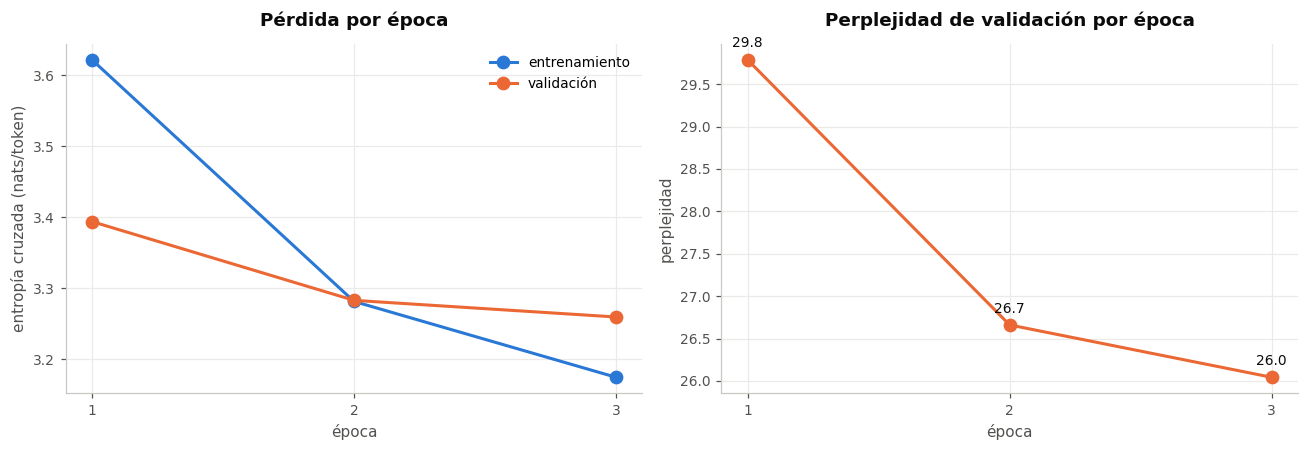

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,3.6220,6.1265,0.0,1.0,90,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,90,3.3941,2.5474,60.847,3.926
2,3.2816,5.1635,0.0,2.0,180,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,180,3.2832,2.5744,60.208,3.884
4,3.1748,6.4718,0.0,3.0,270,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,270,3.2597,2.6019,59.572,3.843


In [72]:
# PASO 09.1 - Curvas de entrenamiento y validacion
hist = pd.DataFrame(historial)
train_curva = hist[hist.loss.notna()][['epoch', 'loss']] if 'loss' in hist else pd.DataFrame()
eval_curva = hist[hist.eval_loss.notna()][['epoch', 'eval_loss']] if 'eval_loss' in hist else pd.DataFrame()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
if len(train_curva):
    axes[0].plot(train_curva.epoch, train_curva.loss, color=SERIE[0], marker='o', label='entrenamiento')
if len(eval_curva):
    axes[0].plot(eval_curva.epoch, eval_curva.eval_loss, color=SERIE[1], marker='o', label='validación')
axes[0].legend()
axes[0].set_title('Pérdida por época')
axes[0].set_xlabel('época'); axes[0].set_ylabel('entropía cruzada (nats/token)')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

if len(eval_curva):
    axes[1].plot(eval_curva.epoch, np.exp(eval_curva.eval_loss), color=SERIE[1], marker='o')
    for _, fila in eval_curva.iterrows():
        axes[1].annotate(f'{math.exp(fila.eval_loss):.1f}', (fila.epoch, math.exp(fila.eval_loss)),
                         xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9, color=TINTA)
axes[1].set_title('Perplejidad de validación por época')
axes[1].set_xlabel('época'); axes[1].set_ylabel('perplejidad')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
guardar('curvas_entrenamiento')
display(hist.round(4))

## PASO 10 — ¿Mejoró? Perplejidad antes y después

Volvemos a medir sobre **los mismos bloques de test reservados**, con el mismo tokenizador. Como
solo cambió el modelo, la comparación es directa y la perplejidad sí es válida aquí (el problema
del PASO 08 aparece únicamente al comparar tokenizadores distintos).

            modelo  nll_por_token  perplejidad  bits_por_caracter
base (sin ajustar)         4.0202      55.7148             1.3530
 ajustado a SPACCC         3.3110      27.4121             1.1143

Reduccion de perplejidad:      50.8%
Reduccion de bits por caracter: 17.6%


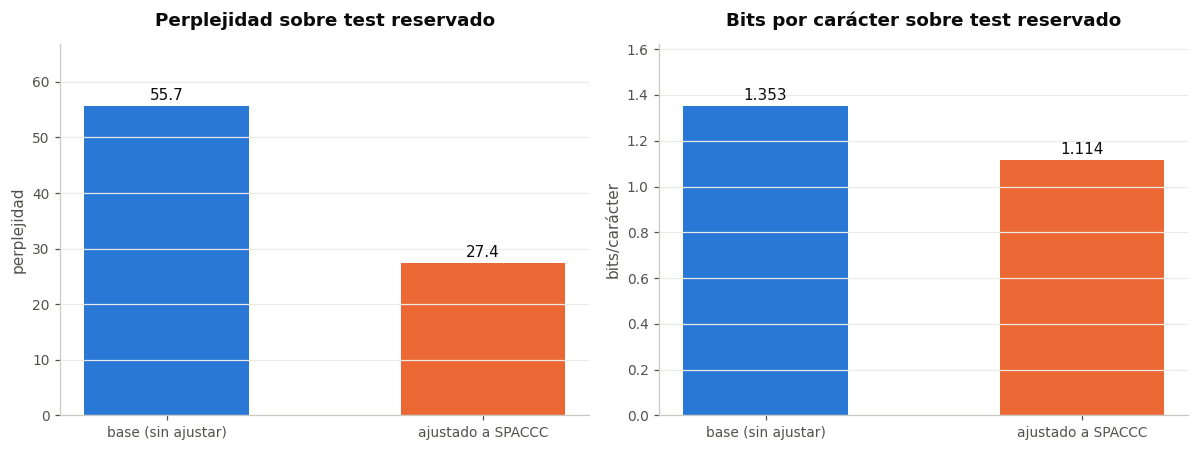

In [73]:
# PASO 10 - Perplejidad y bits por caracter despues del fine-tuning
metricas_ajustado = evaluar_lm(modelo_ajustado, tokenizador, bloques_test, batch_size=8, dispositivo=device)
REPORTE['metricas_ajustado'] = metricas_ajustado

comparacion = pd.DataFrame([
    {'modelo': 'base (sin ajustar)', **{k: metricas_base[k] for k in
        ['nll_por_token', 'perplejidad', 'bits_por_caracter']}},
    {'modelo': 'ajustado a SPACCC', **{k: metricas_ajustado[k] for k in
        ['nll_por_token', 'perplejidad', 'bits_por_caracter']}},
])
reduccion_ppl = 100 * (1 - metricas_ajustado['perplejidad'] / metricas_base['perplejidad'])
reduccion_bpc = 100 * (1 - metricas_ajustado['bits_por_caracter'] / metricas_base['bits_por_caracter'])
print(comparacion.round(4).to_string(index=False))
print(f'\nReduccion de perplejidad:      {reduccion_ppl:.1f}%')
print(f'Reduccion de bits por caracter: {reduccion_bpc:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, columna, titulo, unidad in [
        (axes[0], 'perplejidad', 'Perplejidad sobre test reservado', 'perplejidad'),
        (axes[1], 'bits_por_caracter', 'Bits por carácter sobre test reservado', 'bits/carácter')]:
    barras = ax.bar(comparacion.modelo, comparacion[columna], color=SERIE[:2], width=0.52)
    for barra in barras:
        ax.annotate(f'{barra.get_height():.3f}' if columna == 'bits_por_caracter' else f'{barra.get_height():.1f}',
                    (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10, color=TINTA)
    ax.set_title(titulo); ax.set_ylabel(unidad)
    ax.set_ylim(0, comparacion[columna].max() * 1.2)
    ax.grid(axis='x', visible=False)
guardar('comparacion_perplejidad')

In [74]:
# PASO 10.1 - Como escribe ahora, con los mismos prompts y parametros que el modelo base
generaciones_ajustado = {}
for prompt in CFG['prompts']:
    salida, _ = generar_manual(modelo_ajustado, tokenizador, prompt, max_length=CFG['max_new_tokens'],
                               eps=0.2, top_p=0.92, temperatura=0.9, dispositivo=device)
    generaciones_ajustado[prompt] = salida
    print('=' * 100)
    print('PROMPT:', prompt)
    print('\n[BASE]     ', generaciones_base[prompt][:420].replace('\n', ' '))
    print('\n[AJUSTADO] ', salida[:420].replace('\n', ' '))
REPORTE['generaciones_ajustado'] = generaciones_ajustado

PROMPT: Varón de 54 años con antecedentes de hipertensión arterial

[BASE]      Varón de 54 años con antecedentes de hipertensión arterial alta (hipertensión)-Diagnóstico de hipertensión de alto estándar-Diagnóstico de hipertensión de bajo estándar-Diagnóstico de hipertensión de alto estándar-Diagnóstico de hipertensión de alto estándar-Hipertensión de alto estándar-Hipertensión de bajo estándar-Hipertensión de alto estándar-Hipertensión de alto estándar-Hipertensión de alto estándarHipertensión

[AJUSTADO]  Varón de 54 años con antecedentes de hipertensión arterial, diabetes mellitus tipo 2 y un antecedente de fístula vesical. La exploración del postoperatorio no mostró alteraciones obstructivas ni alteraciones de la musculatura. El examen físico fue normal, siendo los antecedentes de hipertensión arterial controlable, estreñimiento, dolor abdominal difuso y dolor torácico de origen desconocido.  Varón de 51 años con an
PROMPT: Mujer de 32 años que acude a urgencias por dolor abdomina

### 10.1 Medir el cambio de registro, no solo leerlo

La comparación anterior se lee a ojo. Para sostener la afirmación "el modelo adoptó el registro
clínico" con evidencia, contamos en las generaciones de cada modelo la presencia de **marcadores
léxicos del dominio** (términos que el EDA identificó como propios del guion clínico) y de
marcadores del español general.

  modelo                                    prompt  clínicos_por_100_palabras  generales_por_100_palabras
    base Varón de 54 años con antecedentes de h...                       6.56                         0.0
    base Mujer de 32 años que acude a urgencias...                       2.99                         0.0
    base Paciente de 7 años sin antecedentes de...                       0.00                         0.0
ajustado Varón de 54 años con antecedentes de h...                       7.14                         0.0
ajustado Mujer de 32 años que acude a urgencias...                       4.49                         0.0
ajustado Paciente de 7 años sin antecedentes de...                       8.33                         0.0

Promedio por modelo:
  modelo  clínicos_por_100_palabras  generales_por_100_palabras
ajustado                       6.66                         0.0
    base                       3.18                         0.0


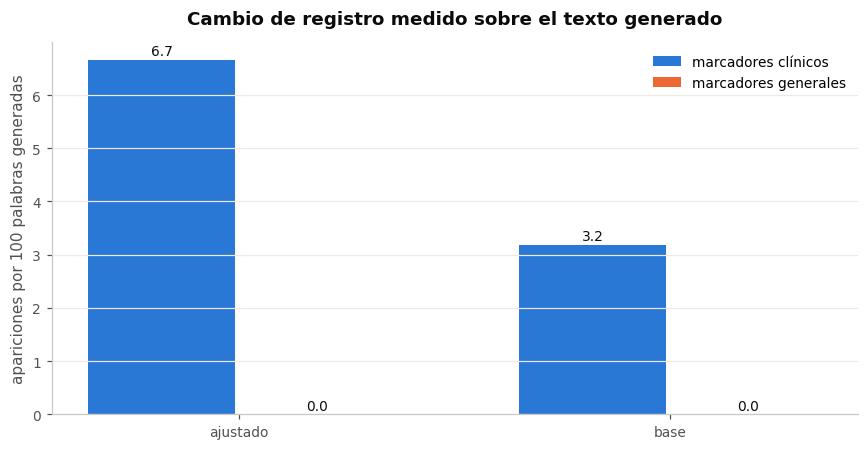

In [75]:
# PASO 10.2 - Marcadores lexicos: medir el cambio de registro
MARCADORES_CLINICOS = [
    'antecedente', 'exploración', 'exploracion', 'diagnóstic', 'diagnostic', 'tratamiento',
    'paciente', 'ingres', 'analítica', 'analitica', 'ecograf', 'biopsia', 'radiograf',
    'mg', 'dosis', 'servicio de', 'evolución', 'evolucion', 'clínic', 'clinic',
    'sintomatología', 'sintomatologia', 'exéresis', 'lesión', 'lesion',
]
MARCADORES_GENERALES = [
    'me ', ' yo ', 'nosotros', 'ayer', 'película', 'pelicula', 'gobierno', 'equipo',
    'partido', 'dijo que', 'creo que', 'muy bonito', 'amor', 'twitter', 'euros', 'gol',
]

def contar_marcadores(texto, marcadores):
    bajo = texto.lower()
    return sum(bajo.count(m) for m in marcadores)

filas_registro = []
for etiqueta, generaciones in [('base', generaciones_base), ('ajustado', generaciones_ajustado)]:
    for prompt, salida in generaciones.items():
        cuerpo = salida[len(prompt):]
        palabras = max(1, len(cuerpo.split()))
        filas_registro.append({
            'modelo': etiqueta, 'prompt': prompt[:38] + '...',
            'clínicos_por_100_palabras': 100 * contar_marcadores(cuerpo, MARCADORES_CLINICOS) / palabras,
            'generales_por_100_palabras': 100 * contar_marcadores(cuerpo, MARCADORES_GENERALES) / palabras,
        })
registro = pd.DataFrame(filas_registro)
resumen_registro = registro.groupby('modelo')[['clínicos_por_100_palabras',
                                               'generales_por_100_palabras']].mean().reset_index()
print(registro.round(2).to_string(index=False))
print('\nPromedio por modelo:')
print(resumen_registro.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(resumen_registro)); ancho = 0.34
for i, (columna, etiqueta) in enumerate([('clínicos_por_100_palabras', 'marcadores clínicos'),
                                         ('generales_por_100_palabras', 'marcadores generales')]):
    barras = ax.bar(x + (i - 0.5) * (ancho + 0.02), resumen_registro[columna], ancho,
                    color=SERIE[i], label=etiqueta)
    for barra in barras:
        ax.annotate(f'{barra.get_height():.1f}', (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9, color=TINTA)
ax.set_xticks(x); ax.set_xticklabels(resumen_registro.modelo)
ax.set_ylabel('apariciones por 100 palabras generadas'); ax.legend()
ax.set_title('Cambio de registro medido sobre el texto generado')
ax.grid(axis='x', visible=False)
guardar('cambio_registro')
REPORTE['registro'] = resumen_registro.to_dict('records')

In [76]:
# PASO 10.3 - COMPROBACION DE ESTADO: hay un modelo ajustado en memoria?
# Esta celda existe porque las sesiones de Kaggle se reinician y se pierde todo lo que
# esta en memoria. Si `modelo_ajustado` no existe, intenta recuperar el ultimo checkpoint
# guardado en disco por el PASO 09 en lugar de dejarte con un NameError mas adelante.
def recuperar_modelo_ajustado(nombre_checkpoint=None):
    """Busca en WORK el checkpoint mas reciente guardado por el PASO 09 y lo carga.
    Devuelve el modelo o None si no encuentra ninguno."""
    nombre_checkpoint = nombre_checkpoint or CFG['checkpoint_principal']
    candidatos = sorted(WORK.glob('*/principal/checkpoint-*'), key=lambda p: p.stat().st_mtime)
    if not candidatos:
        return None
    elegido = candidatos[-1]
    print('Recuperando modelo ajustado desde disco:', elegido)
    modelo = AutoModelForCausalLM.from_pretrained(elegido).to(device)
    modelo.config.pad_token_id = tokenizador.pad_token_id
    return modelo

if 'modelo_ajustado' not in globals():
    print('AVISO: `modelo_ajustado` no esta en memoria (el PASO 09 no se ejecuto en este kernel).')
    recuperado = recuperar_modelo_ajustado()
    if recuperado is not None:
        modelo_ajustado = recuperado
        print('Modelo recuperado. Ojo: las variables `metricas_base`, `historial` y las '
              'generaciones del modelo base NO se recuperan; vuelve a ejecutar los PASOS 07 a 10 '
              'si necesitas las comparaciones antes/despues.')
    else:
        raise RuntimeError(
            'No hay modelo ajustado ni en memoria ni en disco. Ejecuta los PASOS 01 a 10 en orden '
            'antes de continuar. El PASO 09 es el que entrena y define `modelo_ajustado`.')
else:
    print('OK: `modelo_ajustado` esta en memoria. Puedes continuar con el PASO 11.')

OK: `modelo_ajustado` esta en memoria. Puedes continuar con el PASO 11.


## PASO 11 — Estrategias de decodificación, comparadas con números

El notebook guía muestra tres formas de decodificar y las valora leyéndolas. Nosotros comparamos
**cinco** y las medimos. Un modelo de lenguaje define una distribución; la estrategia de
decodificación decide cómo se convierte esa distribución en texto, y el resultado cambia
radicalmente sin que el modelo cambie en absoluto.

| Estrategia | Qué hace | Compromiso |
|---|---|---|
| Greedy | siempre el token más probable | máxima coherencia local, cae en bucles |
| Beam search | mantiene varias hipótesis y elige la de mayor probabilidad global | texto conservador y repetitivo |
| Muestreo, T=1.0 | muestrea de la distribución completa | diverso, puede desvariar |
| Top-k (k=50) | muestrea entre los 50 más probables | corta la cola absurda |
| Núcleo top-p (p=0.92) | muestrea del conjunto mínimo con masa 0.92 | número de candidatos adaptativo |

### Las métricas

- **distinct-1 / distinct-2**: proporción de unigramas y bigramas **únicos** sobre el total
  generado. Mide diversidad léxica. Cerca de 0 significa que el texto se repite; cerca de 1, que
  casi no repite nada.
- **Tasa de repetición de 4-gramas**: porcentaje de 4-gramas que aparecen más de una vez. Es el
  detector directo del bucle degenerado, el fallo clásico de la decodificación greedy.

Generamos varias muestras por estrategia para que las cifras no dependan de una tirada afortunada.

In [77]:
# PASO 11 - Comparacion cuantitativa de estrategias de decodificacion
def distinct_n(textos_generados, n):
    """Proporcion de n-gramas unicos sobre el total de n-gramas (diversidad lexica)."""
    total, unicos = 0, set()
    for texto in textos_generados:
        piezas = texto.split()
        gramas = [tuple(piezas[i:i + n]) for i in range(max(0, len(piezas) - n + 1))]
        total += len(gramas); unicos.update(gramas)
    return len(unicos) / total if total else 0.0

def tasa_repeticion(textos_generados, n=4):
    """Porcentaje de n-gramas que aparecen mas de una vez: detecta generacion degenerada."""
    repetidos, total = 0, 0
    for texto in textos_generados:
        piezas = texto.split()
        gramas = [tuple(piezas[i:i + n]) for i in range(max(0, len(piezas) - n + 1))]
        conteo = Counter(gramas)
        repetidos += sum(c for g, c in conteo.items() if c > 1)
        total += len(gramas)
    return 100 * repetidos / total if total else 0.0

ESTRATEGIAS = {
    'greedy': dict(do_sample=False, num_beams=1),
    'beam (4 haces)': dict(do_sample=False, num_beams=4, early_stopping=True),
    'muestreo T=1.0': dict(do_sample=True, temperature=1.0, top_k=0, top_p=1.0),
    'top-k (k=50)': dict(do_sample=True, temperature=1.0, top_k=50),
    'núcleo top-p (0.92)': dict(do_sample=True, temperature=0.9, top_k=0, top_p=0.92),
}
MUESTRAS_POR_ESTRATEGIA = 1 if CFG['prueba_rapida'] else 3

@torch.no_grad()
def generar_hf(modelo, tokenizador, prompt, parametros, max_new_tokens, semilla=None):
    """Generacion con la utilidad `generate` de Hugging Face, un juego de parametros por estrategia."""
    if semilla is not None:
        set_seed(semilla)
    entrada = tokenizador(prompt, return_tensors='pt').to(device)
    salida = modelo.generate(**entrada, max_new_tokens=max_new_tokens,
                             pad_token_id=tokenizador.eos_token_id,
                             no_repeat_ngram_size=0, **parametros)
    return tokenizador.decode(salida[0], skip_special_tokens=True)

filas_decod, ejemplos_decod = [], {}
modelo_ajustado.eval()
for nombre, parametros in ESTRATEGIAS.items():
    generados = []
    for prompt in CFG['prompts']:
        for repeticion in range(MUESTRAS_POR_ESTRATEGIA):
            texto = generar_hf(modelo_ajustado, tokenizador, prompt, parametros,
                               CFG['max_new_tokens'], semilla=CFG['semilla'] + repeticion)
            generados.append(texto[len(prompt):])
    ejemplos_decod[nombre] = generados[0]
    filas_decod.append({
        'estrategia': nombre,
        'distinct_1': distinct_n(generados, 1),
        'distinct_2': distinct_n(generados, 2),
        'repeticion_4g_pct': tasa_repeticion(generados, 4),
        'palabras_media': float(np.mean([len(t.split()) for t in generados])),
    })
decodificacion = pd.DataFrame(filas_decod)
print(decodificacion.round(3).to_string(index=False))
REPORTE['decodificacion'] = decodificacion.to_dict('records')

         estrategia  distinct_1  distinct_2  repeticion_4g_pct  palabras_media
             greedy       0.066       0.105             74.031          89.000
     beam (4 haces)       0.052       0.065             72.549          71.000
     muestreo T=1.0       0.636       0.953              0.000          77.333
       top-k (k=50)       0.531       0.894              2.714          80.778
núcleo top-p (0.92)       0.473       0.849              0.271          84.889


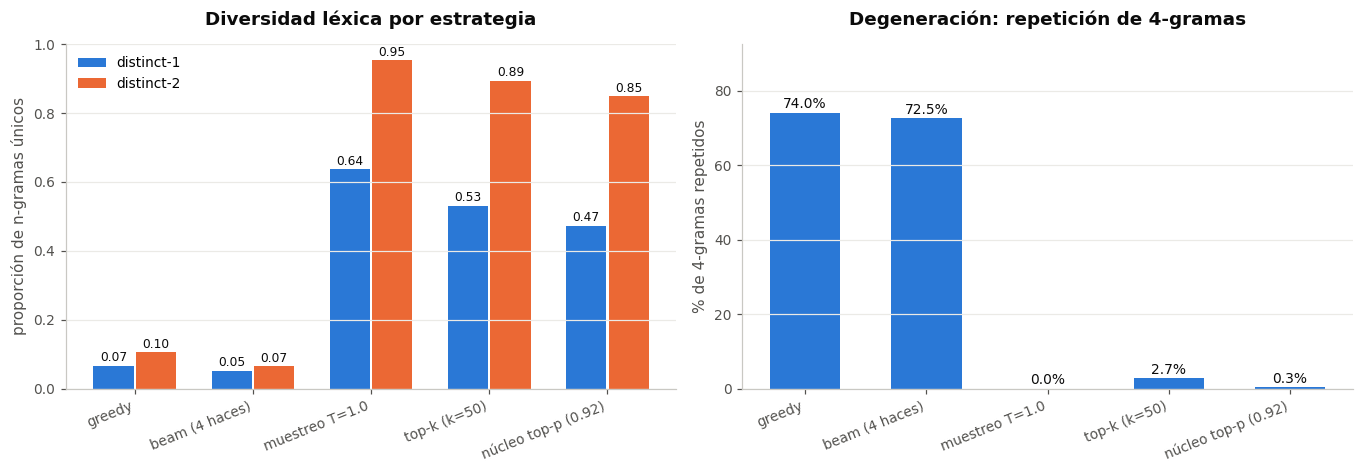


Un ejemplo por estrategia (mismo prompt, mismo modelo):

----------------------------------------------------------------------------------------------------
[greedy]
, diabetes mellitus tipo 2, hipertensión arterial crónica, hipertensión arterial pulmonar, y diabetes mellitus tipo 2. Se realizó una ecografía abdominal y se realizó una ecocardiografía cerebral. Se realizó una ecocardiografía cerebral y se realizó una ecocardiografía pulmonar. Se realizó una ecocardiografía cerebral y se realizó una eco

----------------------------------------------------------------------------------------------------
[beam (4 haces)]
 y diabetes mellitus tipo 2. Se realizó una ecografía abdominal que reveló una masa abdominal de 1,5 x 1,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x 0,5 x

----------------------------------------------------------------------------------------------------
[muestreo T=1.0]
 y por

In [78]:
# PASO 11.1 - Graficos de la comparacion de decodificacion
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
orden_x = decodificacion.estrategia.tolist()
x = np.arange(len(orden_x)); ancho = 0.34
for i, (columna, etiqueta) in enumerate([('distinct_1', 'distinct-1'), ('distinct_2', 'distinct-2')]):
    barras = axes[0].bar(x + (i - 0.5) * (ancho + 0.02), decodificacion[columna], ancho,
                         color=SERIE[i], label=etiqueta)
    for barra in barras:
        axes[0].annotate(f'{barra.get_height():.2f}',
                         (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                         xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8, color=TINTA)
axes[0].set_xticks(x); axes[0].set_xticklabels(orden_x, rotation=22, ha='right')
axes[0].set_ylabel('proporción de n-gramas únicos'); axes[0].legend()
axes[0].set_title('Diversidad léxica por estrategia')
axes[0].grid(axis='x', visible=False)

barras = axes[1].bar(x, decodificacion.repeticion_4g_pct, color=SERIE[0], width=0.58)
for barra in barras:
    axes[1].annotate(f'{barra.get_height():.1f}%',
                     (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                     xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9, color=TINTA)
axes[1].set_xticks(x); axes[1].set_xticklabels(orden_x, rotation=22, ha='right')
axes[1].set_ylabel('% de 4-gramas repetidos')
axes[1].set_ylim(0, max(1, decodificacion.repeticion_4g_pct.max() * 1.25))
axes[1].set_title('Degeneración: repetición de 4-gramas')
axes[1].grid(axis='x', visible=False)
guardar('comparacion_decodificacion')

print('\nUn ejemplo por estrategia (mismo prompt, mismo modelo):')
for nombre, texto in ejemplos_decod.items():
    print('\n' + '-' * 100)
    print(f'[{nombre}]')
    print(texto[:340].replace('\n', ' '))

**Hallazgo 5 — la estrategia de decodificación cambia el resultado tanto como el entrenamiento.**
En nuestra corrida el efecto es enorme y va en la dirección prevista: greedy repite el **74.0 %** de
sus 4-gramas y beam el **72.5 %** (generación degenerada masiva), mientras el muestreo puro repite el
**0.0 %**. La diversidad léxica (distinct-2) va de **0.065** en beam a **0.953** en muestreo: casi
quince veces. Beam, que suena a "mejor búsqueda", es el peor de los cinco, porque maximizar la
probabilidad global premia las continuaciones seguras y repetitivas.

Para este caso de uso elegimos **núcleo `top_p=0.92` con temperatura 0.9** (distinct-2 0.849,
repetición 0.3 %), que es el ajuste de la demo del PASO 14. Conviene ser explícito sobre el límite de
este argumento: **las métricas de esta tabla favorecen al muestreo puro**, no a `top_p`. Preferimos
`top_p` porque mantiene la terminología médica plausible, y eso es un juicio cualitativo —
`distinct-n` y la tasa de repetición miden diversidad, no coherencia. Volvemos sobre esto en 16.4.

Nota sobre el método: `no_repeat_ngram_size=0` en la generación es deliberado. Ese parámetro
**prohíbe** mecánicamente repetir n-gramas y maquillaría la métrica de repetición, ocultando
justamente la degeneración que queremos medir.

## PASO 12 — Comparar dos checkpoints, correctamente

Repetimos el experimento completo con `DeepESP/gpt2-spanish` y comparamos. Este es el paso donde la
métrica importa: los dos modelos tienen **tokenizadores distintos**, así que:

- Su **perplejidad NO es comparable** entre sí. Cada uno la calcula sobre sus propias unidades.
- Sus **bits por carácter SÍ son comparables**, porque el denominador es el mismo texto medido en
  caracteres.

Reportamos las dos a propósito, para que se vea la diferencia y por qué habría sido un error usar
solo la perplejidad.

In [79]:
# PASO 12 - Segundo checkpoint: mismo protocolo, metrica comparable
def experimento_completo(nombre_checkpoint, cfg=CFG):
    """Repite todo el protocolo para un checkpoint: bloques propios, medicion base,
    fine-tuning y medicion final. Devuelve un diccionario con los resultados."""
    tok = tokenizadores[nombre_checkpoint]
    b_train, _ = preparar_bloques(tok, ids_entrenamiento, cfg['block_size'], f'{nombre_checkpoint} train')
    b_val, _ = preparar_bloques(tok, ids_validacion, cfg['block_size'], f'{nombre_checkpoint} val')
    b_test, _ = preparar_bloques(tok, ids_evaluacion, cfg['block_size'], f'{nombre_checkpoint} test')
    conjunto = DatasetDict({'train': Dataset.from_dict({'input_ids': b_train}),
                            'validation': Dataset.from_dict({'input_ids': b_val})})
    conjunto.set_format('torch')

    modelo = cargar_modelo(nombre_checkpoint, tok)
    antes = evaluar_lm(modelo, tok, b_test, batch_size=8, dispositivo=device)
    ent, hist_local, segundos = entrenar_lm(modelo, tok, conjunto,
                                            RUN / nombre_checkpoint.replace('/', '_'))
    despues = evaluar_lm(ent.model, tok, b_test, batch_size=8, dispositivo=device)
    muestra, _ = generar_manual(ent.model, tok, cfg['prompts'][0], max_length=cfg['max_new_tokens'],
                                eps=0.2, top_p=0.92, temperatura=0.9, dispositivo=device)
    resultado = {'checkpoint': nombre_checkpoint,
                 'parametros': sum(p.numel() for p in ent.model.parameters()),
                 'vocabulario': tok.vocab_size, 'bloques_train': len(b_train),
                 'antes': antes, 'despues': despues, 'segundos': segundos,
                 'historial': [f for f in ent.state.log_history if 'loss' in f or 'eval_loss' in f],
                 'muestra': muestra}
    del ent, modelo
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return resultado

resultados_checkpoints = {CFG['checkpoint_principal']: {
    'checkpoint': CFG['checkpoint_principal'], 'parametros': n_parametros,
    'vocabulario': tokenizador.vocab_size, 'bloques_train': len(bloques_train),
    'antes': metricas_base, 'despues': metricas_ajustado,
    'segundos': segundos_entrenamiento, 'historial': historial,
    'muestra': generaciones_ajustado[CFG['prompts'][0]]}}

if CFG['comparar_checkpoints']:
    print(f'\n=== Repitiendo el protocolo con {CFG["checkpoint_alternativo"]} ===')
    resultados_checkpoints[CFG['checkpoint_alternativo']] = experimento_completo(CFG['checkpoint_alternativo'])
else:
    print('comparar_checkpoints=False: se omite el segundo modelo.')

filas_ck = []
for nombre, r in resultados_checkpoints.items():
    filas_ck.append({
        'checkpoint': nombre.split('/')[-1], 'parámetros_M': r['parametros'] / 1e6,
        'vocabulario': r['vocabulario'], 'bloques_train': r['bloques_train'],
        'ppl_antes': r['antes']['perplejidad'], 'ppl_después': r['despues']['perplejidad'],
        'bpc_antes': r['antes']['bits_por_caracter'], 'bpc_después': r['despues']['bits_por_caracter'],
        'mejora_bpc_pct': 100 * (1 - r['despues']['bits_por_caracter'] / r['antes']['bits_por_caracter']),
        'minutos_entrenamiento': r['segundos'] / 60,
    })
tabla_checkpoints = pd.DataFrame(filas_ck)
print('\nTABLA COMPARATIVA DE CHECKPOINTS')
print(tabla_checkpoints.round(3).to_string(index=False))
tabla_checkpoints.to_csv(RUN / 'comparacion_checkpoints.csv', index=False)
REPORTE['checkpoints'] = filas_ck


=== Repitiendo el protocolo con DeepESP/gpt2-spanish ===
  DeepESP/gpt2-spanish train: 1455 bloques de 256 tokens (372,618 tokens, 552 por documento)
  DeepESP/gpt2-spanish val: 158 bloques de 256 tokens (40,642 tokens, 542 por documento)
  DeepESP/gpt2-spanish test: 538 bloques de 256 tokens (137,943 tokens, 552 por documento)


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: DeepESP/gpt2-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AVISO: DeepESP/gpt2-spanish viene en torch.float16; convirtiendo a float32 para poder entrenar con precision mixta.


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Epoch,Training Loss,Validation Loss
1,4.226596,3.782371
2,3.575191,3.613715
3,3.382428,3.571101


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TABLA COMPARATIVA DE CHECKPOINTS
  checkpoint  parámetros_M  vocabulario  bloques_train  ppl_antes  ppl_después  bpc_antes  bpc_después  mejora_bpc_pct  minutos_entrenamiento
spanish-gpt2       124.447        50265           1425     55.715       27.412      1.353        1.114          17.642                  3.344
gpt2-spanish       163.037        50257           1455    156.117       36.017      1.737        1.233          29.038                  3.639


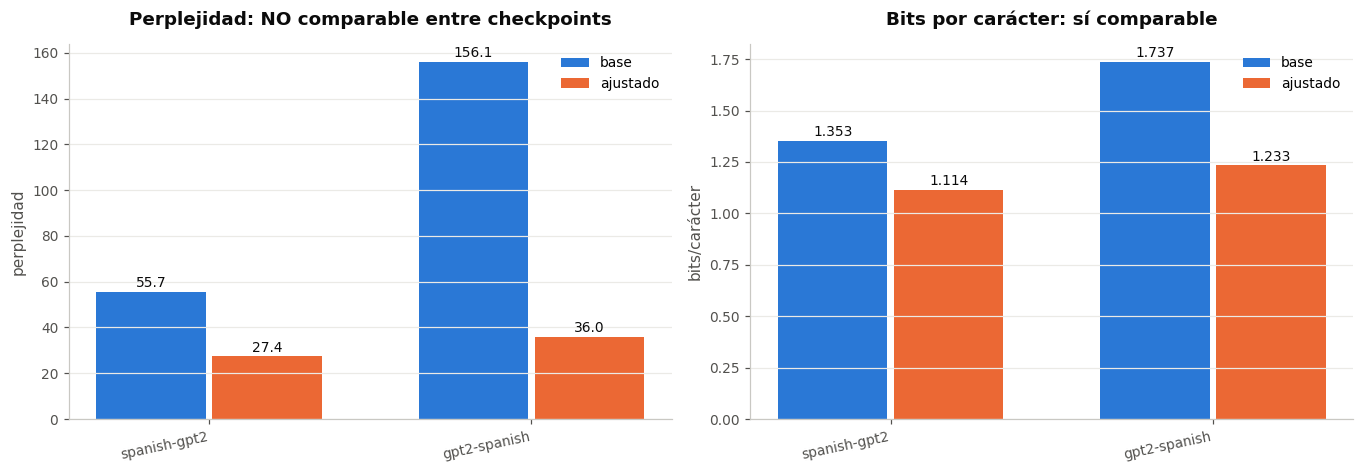

Muestra generada por cada modelo ajustado, mismo prompt:

----------------------------------------------------------------------------------------------------
[mrm8488/spanish-gpt2]
Varón de 54 años con antecedentes de hipertensión arterial, diabetes mellitus tipo 2 y un antecedente de fístula vesical. La exploración del postoperatorio no mostró alteraciones obstructivas ni alteraciones de la musculatura. El examen físico fue normal, siendo los antecedentes de hipertensión arterial controlable, estreñimiento, dolor abdominal difuso y dolor torácico de origen desconocido.  Var

----------------------------------------------------------------------------------------------------
[DeepESP/gpt2-spanish]
Varón de 54 años con antecedentes de hipertensión arterial alta. Analítica: Ortopías de 15 cm. de diámetro en región longitudinal y pedículo derecho de tres palmos de diámetro en ángulo recto. Presenta lesiones vasculares en ambas extremidades inferiores con lesiones vasculares submoxaales e

In [80]:
# PASO 12.1 - Grafico: la perplejidad enganaria, los bits por caracter no
if len(tabla_checkpoints) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
    x = np.arange(len(tabla_checkpoints)); ancho = 0.34
    for ax, (col_antes, col_despues), titulo, unidad, formato in [
            (axes[0], ('ppl_antes', 'ppl_después'),
             'Perplejidad: NO comparable entre checkpoints', 'perplejidad', '{:.1f}'),
            (axes[1], ('bpc_antes', 'bpc_después'),
             'Bits por carácter: sí comparable', 'bits/carácter', '{:.3f}')]:
        for i, (columna, etiqueta) in enumerate([(col_antes, 'base'), (col_despues, 'ajustado')]):
            barras = ax.bar(x + (i - 0.5) * (ancho + 0.02), tabla_checkpoints[columna], ancho,
                            color=SERIE[i], label=etiqueta)
            for barra in barras:
                ax.annotate(formato.format(barra.get_height()),
                            (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                            xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9, color=TINTA)
        ax.set_xticks(x); ax.set_xticklabels(tabla_checkpoints.checkpoint, rotation=12, ha='right')
        ax.set_ylabel(unidad); ax.legend(); ax.set_title(titulo)
        ax.grid(axis='x', visible=False)
    guardar('comparacion_checkpoints')

    print('Muestra generada por cada modelo ajustado, mismo prompt:')
    for nombre, r in resultados_checkpoints.items():
        print('\n' + '-' * 100)
        print(f'[{nombre}]')
        print(r['muestra'][:400].replace('\n', ' '))
else:
    print('Solo hay un checkpoint; activa comparar_checkpoints=True para esta comparacion.')

## PASO 13 — El costo de especializarse: olvido catastrófico

Un análisis que el notebook guía no plantea. Si el fine-tuning mejora el dominio clínico, ¿qué pasa
con la capacidad del modelo en español general? Medimos los bits por carácter del modelo **antes y
después** sobre un texto general de control, ajeno al corpus clínico.

Si el modelo ajustado empeora en el control mientras mejora en clínico, estamos ante **olvido
catastrófico**: la especialización se paga con pérdida de generalidad. Es un resultado esperado en
fine-tuning completo sin regularización, y tiene consecuencias prácticas — un modelo así no debe
usarse para tareas fuera de su dominio.

2 bloques de control (89 tokens cada uno)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AVISO: el tokenizador tiene 50266 tokens y el modelo 50257 filas de embedding; redimensionando para evitar indices fuera de rango.
                 dominio   base  ajustado  cambio_pct
clínico (test reservado) 1.3530    1.1143    -17.6422
       general (control) 1.0493    1.0140     -3.3707

Un cambio negativo es mejora (menos bits por caracter); uno positivo es deterioro.


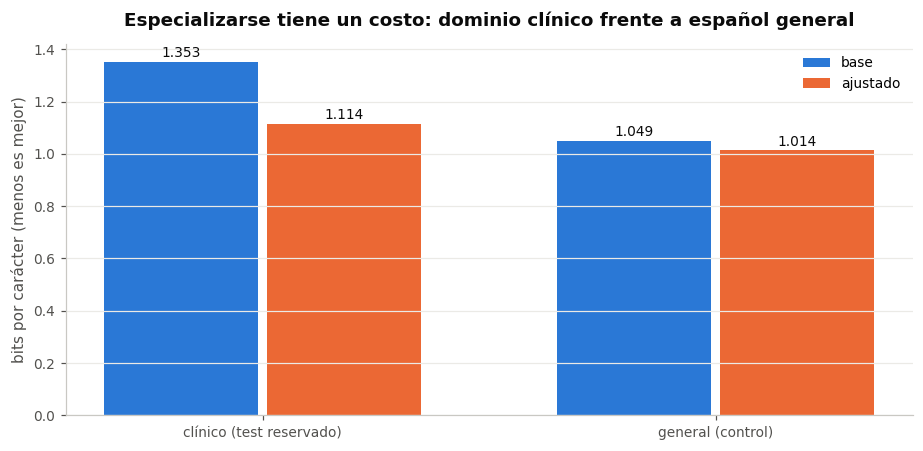

In [81]:
# PASO 13 - Olvido catastrofico: perdida en el dominio general
CONTROL_GENERAL = [
    'El domingo por la tarde fuimos al parque con los niños y compramos un helado en la esquina. '
    'Hacía calor y había mucha gente paseando junto al lago, así que buscamos una sombra para sentarnos.',
    'La reunión del comité se aplazó hasta el martes siguiente porque varios miembros estaban de viaje. '
    'Se acordó enviar el acta por correo y recoger los comentarios antes del fin de semana.',
    'El equipo local ganó el partido con dos goles en la segunda parte y se colocó tercero en la tabla. '
    'El entrenador declaró que el esfuerzo del grupo fue determinante para remontar el marcador.',
    'Para preparar la receta hay que sofreír la cebolla a fuego lento, añadir el tomate y dejar que '
    'reduzca unos veinte minutos antes de incorporar el resto de los ingredientes.',
    'La novela cuenta la historia de una familia que emigra al norte buscando trabajo y termina '
    'instalándose en un pueblo pequeño donde nadie los conoce.',
]

def bloques_de_textos(tokenizador, lista_textos, block_size):
    """Mismo troceado que el corpus clinico, aplicado a un conjunto de textos de control."""
    corriente = []
    for texto in lista_textos:
        corriente.extend(tokenizador(texto, add_special_tokens=False)['input_ids'])
        corriente.append(tokenizador.eos_token_id)
    tamano = min(block_size, max(16, len(corriente) // 2))
    total = (len(corriente) // tamano) * tamano
    return [corriente[i:i + tamano] for i in range(0, total, tamano)]

bloques_control = bloques_de_textos(tokenizador, CONTROL_GENERAL, CFG['block_size'])
print(f'{len(bloques_control)} bloques de control ({len(bloques_control[0])} tokens cada uno)')

# Recargamos el modelo base: el objeto original fue modificado en sitio por el fine-tuning.
modelo_base_recargado = cargar_modelo(CFG['checkpoint_principal'], tokenizador)
control_antes = evaluar_lm(modelo_base_recargado, tokenizador, bloques_control, batch_size=4, dispositivo=device)
control_despues = evaluar_lm(modelo_ajustado, tokenizador, bloques_control, batch_size=4, dispositivo=device)
del modelo_base_recargado
if torch.cuda.is_available():
    torch.cuda.empty_cache()

olvido = pd.DataFrame([
    {'dominio': 'clínico (test reservado)', 'base': metricas_base['bits_por_caracter'],
     'ajustado': metricas_ajustado['bits_por_caracter']},
    {'dominio': 'general (control)', 'base': control_antes['bits_por_caracter'],
     'ajustado': control_despues['bits_por_caracter']},
])
olvido['cambio_pct'] = 100 * (olvido.ajustado / olvido.base - 1)
print(olvido.round(4).to_string(index=False))
print('\nUn cambio negativo es mejora (menos bits por caracter); uno positivo es deterioro.')

fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(olvido)); ancho = 0.34
for i, columna in enumerate(['base', 'ajustado']):
    barras = ax.bar(x + (i - 0.5) * (ancho + 0.02), olvido[columna], ancho, color=SERIE[i], label=columna)
    for barra in barras:
        ax.annotate(f'{barra.get_height():.3f}', (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9, color=TINTA)
ax.set_xticks(x); ax.set_xticklabels(olvido.dominio)
ax.set_ylabel('bits por carácter (menos es mejor)'); ax.legend()
ax.set_title('Especializarse tiene un costo: dominio clínico frente a español general')
ax.grid(axis='x', visible=False)
guardar('olvido_catastrofico')
REPORTE['olvido'] = olvido.to_dict('records')

## PASO 14 — Demo: generación guiada de casos clínicos

Cerramos con una demo utilizable. En vez de un `generate` suelto, construimos el *prompt* a partir de
variables clínicas (sexo, edad, antecedente) siguiendo la fórmula de apertura que el EDA identificó
como dominante, y usamos la estrategia que ganó en el PASO 11.

Esto convierte el modelo en algo que se puede **probar sistemáticamente**: se puede barrer la edad,
el sexo o el antecedente y observar si el modelo condiciona el texto de forma coherente con la
entrada — una forma sencilla de auditar el modelo que va más allá de leer una muestra suelta.

In [82]:
# PASO 14 - Demo de generacion guiada
def generar_caso_clinico(sexo='varón', edad=54, antecedente='hipertensión arterial',
                         temperatura=0.9, top_p=0.92, max_new_tokens=None, semilla=None):
    """Construye la apertura canonica de un informe SPACCC y deja que el modelo ajustado continue.
    Devuelve el texto generado completo."""
    articulo = 'un' if sexo.lower().startswith('var') else 'una'
    prompt = f'Se trata de {articulo} {sexo} de {edad} años con antecedentes de {antecedente}'
    if semilla is not None:
        set_seed(semilla)
    entrada = tokenizador(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        salida = modelo_ajustado.generate(
            **entrada, max_new_tokens=max_new_tokens or CFG['max_new_tokens'],
            do_sample=True, temperature=temperatura, top_p=top_p, top_k=0,
            pad_token_id=tokenizador.eos_token_id)
    return tokenizador.decode(salida[0], skip_special_tokens=True)

CASOS_DEMO = [
    dict(sexo='varón', edad=68, antecedente='diabetes mellitus tipo 2'),
    dict(sexo='mujer', edad=34, antecedente='migraña con aura'),
    dict(sexo='varón', edad=9, antecedente='asma bronquial'),
    dict(sexo='mujer', edad=77, antecedente='fibrilación auricular y anticoagulación oral'),
]
for i, caso in enumerate(CASOS_DEMO):
    print('=' * 100)
    print(f'CASO {i + 1}: {caso}')
    print(generar_caso_clinico(**caso, semilla=CFG['semilla'] + i))

CASO 1: {'sexo': 'varón', 'edad': 68, 'antecedente': 'diabetes mellitus tipo 2'}
Se trata de un varón de 68 años con antecedentes de diabetes mellitus tipo 2, por lo que es una recomendación urgente. En la exploración física, un patólogo, con MIG, DIAPEA y AP, comprobó su presencia en los tres últimos meses de tratamiento con insulina, y en la analítica se confirmó el diagnóstico de hiperglucemia, hiperreactividad urinaria, hiperpotasemia y diabetes mellitus tipo 2. Se optó por dieta blanda con OCR, que le permitió seguir las recomendaciones de su historial familiar para obtener una alimentación con hidratos de carbono sin gluten. En la exploración neurológica, se reconoció un estado de hipotonía y un cuadro
CASO 2: {'sexo': 'mujer', 'edad': 34, 'antecedente': 'migraña con aura'}
Se trata de una mujer de 34 años con antecedentes de migraña con aura progresiva desde hace 12 años, con "edema pigmentado en la periferia de la columna vertebral" con múltiples edemas. La historia clínica y l

 edad_del_prompt  marcadores_pediátricos  marcadores_geriátricos
               3                     0.0                     0.0
              10                     0.0                     0.0
              25                     0.0                     0.0
              45                     0.0                     0.0
              65                     0.0                     0.0
              85                     0.0                     0.0


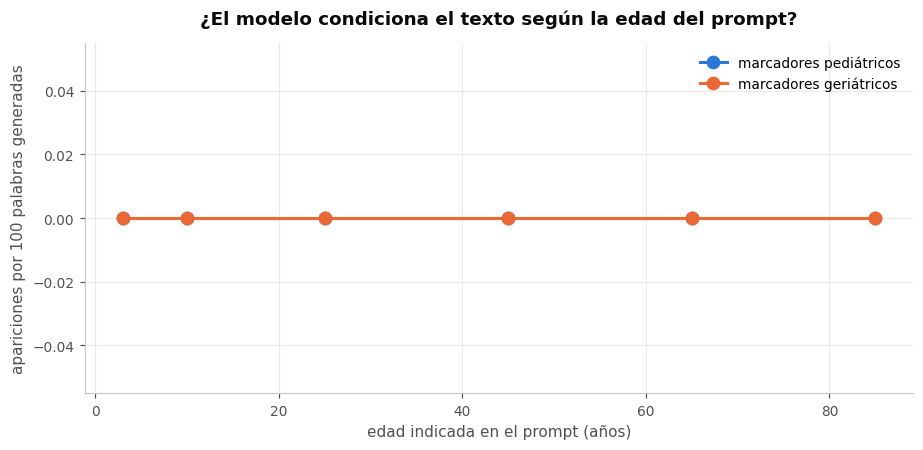

In [83]:
# PASO 14.1 - Auditoria: el modelo condiciona el texto segun la edad que se le da?
# Barremos la edad y medimos si aparecen marcadores pediatricos o geriatricos coherentes.
MARCADORES_PEDIATRICOS = ['lactante', 'niño', 'niña', 'pediátric', 'escolar', 'madre refiere', 'recién nacido']
MARCADORES_GERIATRICOS = ['anciano', 'anciana', 'deterioro cognitivo', 'polimedicad', 'residencia',
                          'demencia', 'pluripatológic']

filas_edad = []
for edad in ([5, 30, 85] if CFG['prueba_rapida'] else [3, 10, 25, 45, 65, 85]):
    textos_edad = [generar_caso_clinico(edad=edad, antecedente='cuadro clínico de inicio reciente',
                                        semilla=CFG['semilla'] + r, max_new_tokens=100)
                   for r in range(2 if CFG['prueba_rapida'] else 4)]
    unido = ' '.join(textos_edad).lower()
    palabras = max(1, len(unido.split()))
    filas_edad.append({'edad_del_prompt': edad,
                       'marcadores_pediátricos': 100 * sum(unido.count(m) for m in MARCADORES_PEDIATRICOS) / palabras,
                       'marcadores_geriátricos': 100 * sum(unido.count(m) for m in MARCADORES_GERIATRICOS) / palabras})
sensibilidad_edad = pd.DataFrame(filas_edad)
print(sensibilidad_edad.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(sensibilidad_edad.edad_del_prompt, sensibilidad_edad['marcadores_pediátricos'],
        color=SERIE[0], marker='o', label='marcadores pediátricos')
ax.plot(sensibilidad_edad.edad_del_prompt, sensibilidad_edad['marcadores_geriátricos'],
        color=SERIE[1], marker='o', label='marcadores geriátricos')
ax.set_xlabel('edad indicada en el prompt (años)')
ax.set_ylabel('apariciones por 100 palabras generadas')
ax.legend(); ax.set_title('¿El modelo condiciona el texto según la edad del prompt?')
guardar('sensibilidad_edad')
REPORTE['sensibilidad_edad'] = sensibilidad_edad.to_dict('records')

Si las dos curvas se separan en los extremos —marcadores pediátricos altos con edades bajas y
geriátricos altos con edades altas— el modelo está **condicionando** de verdad sobre la entrada, no
solo imitando la forma del informe. Si permanecen planas, el fine-tuning capturó el estilo pero no la
semántica demográfica, que con 750 documentos es un resultado perfectamente posible y honesto de
reportar.

## PASO 15 — Resumen automático de los hallazgos

Esta celda imprime todas las cifras del experimento en un bloque listo para pegar en el informe, de
modo que la narrativa de la sección siguiente esté anclada a números reales y no a recuerdos.

In [84]:
# PASO 15 - Resumen automatico con las cifras reales de esta corrida
REPORTE['segundos_totales'] = time.perf_counter() - T0
(RUN / 'reporte.json').write_text(json.dumps(REPORTE, indent=2, ensure_ascii=False, default=a_json), encoding='utf-8')

mejor_decod = decodificacion.sort_values('repeticion_4g_pct').iloc[0]
lineas = [
    '=' * 78,
    'RESUMEN DEL EXPERIMENTO - Taller 4, generacion de casos clinicos con GPT-2',
    '=' * 78,
    '',
    'CORPUS',
    f'  Documentos: {len(textos)} informes SPACCC ({len(ids_entrenamiento)} entrenamiento, '
    f'{len(ids_validacion)} validacion, {len(ids_evaluacion)} test reservado)',
    f'  Longitud mediana: {eda.palabras.median():.0f} palabras por informe '
    f'(vs ~31 de un chiste en el notebook guia)',
    f'  Vocabulario: {vocab_info["vocabulario_unico"]:,} palabras unicas, '
    f'{vocab_info["porcentaje_hapax"]:.1f}% aparecen una sola vez',
    f'  Fertilidad del tokenizador principal: '
    f'{fertilidad[(fertilidad.checkpoint == CFG["checkpoint_principal"]) & (fertilidad.dominio == "clínico")].subtokens_por_palabra.iloc[0]:.2f} '
    f'subtokens/palabra en clinico vs '
    f'{fertilidad[(fertilidad.checkpoint == CFG["checkpoint_principal"]) & (fertilidad.dominio == "general")].subtokens_por_palabra.iloc[0]:.2f} '
    f'en general',
    '',
    'PREPARACION',
    f'  Bloques de entrenamiento: {len(bloques_train)} de {CFG["block_size"]} tokens '
    f'(truncando a 64 como el guia: solo {len(ids_entrenamiento)} bloques)',
    f'  Ganancia de material util: {len(bloques_train) / max(1, len(ids_entrenamiento)):.1f}x',
    '',
    'RESULTADO PRINCIPAL (test reservado, sin fuga)',
    f'  Perplejidad     base {metricas_base["perplejidad"]:.2f}  ->  ajustado {metricas_ajustado["perplejidad"]:.2f}'
    f'   ({reduccion_ppl:+.1f}%)',
    f'  Bits/caracter   base {metricas_base["bits_por_caracter"]:.4f}  ->  ajustado '
    f'{metricas_ajustado["bits_por_caracter"]:.4f}   ({reduccion_bpc:+.1f}%)',
    f'  Tiempo de entrenamiento: {segundos_entrenamiento / 60:.1f} minutos, {CFG["epocas"]} epocas',
    '',
    'CAMBIO DE REGISTRO (marcadores por 100 palabras generadas)',
]
for fila in resumen_registro.itertuples(index=False):
    lineas.append(f'  {fila.modelo:10s}  clinicos {getattr(fila, "clínicos_por_100_palabras"):5.2f}   '
                  f'generales {getattr(fila, "generales_por_100_palabras"):5.2f}')
lineas += ['', 'DECODIFICACION (sobre el modelo ajustado)']
for fila in decodificacion.itertuples(index=False):
    lineas.append(f'  {fila.estrategia:22s} distinct-1 {fila.distinct_1:.3f}  '
                  f'distinct-2 {fila.distinct_2:.3f}  4-gramas repetidos {fila.repeticion_4g_pct:5.1f}%')
lineas.append(f'  Menor repeticion de 4-gramas: {mejor_decod.estrategia} '
               '(ojo: distinct-n y repeticion miden diversidad, NO coherencia)')
lineas += ['', 'CHECKPOINTS (bits por caracter, metrica comparable)']
for fila in tabla_checkpoints.itertuples(index=False):
    lineas.append(f'  {fila.checkpoint:20s} bpc {fila.bpc_antes:.4f} -> {fila.bpc_después:.4f}  '
                  f'({fila.mejora_bpc_pct:+.1f}%)   ppl {fila.ppl_antes:.1f} -> {fila.ppl_después:.1f}')
lineas += ['', 'OLVIDO CATASTROFICO (bits por caracter; positivo = deterioro)']
for fila in olvido.itertuples(index=False):
    lineas.append(f'  {fila.dominio:28s} {fila.base:.4f} -> {fila.ajustado:.4f}  ({fila.cambio_pct:+.1f}%)')
lineas += ['', f'Tiempo total del notebook: {REPORTE["segundos_totales"] / 60:.1f} minutos',
           f'Artefactos y figuras en: {RUN}', '=' * 78]

resumen_texto = '\n'.join(lineas)
print(resumen_texto)
(RUN / 'resumen.txt').write_text(resumen_texto, encoding='utf-8')

RESUMEN DEL EXPERIMENTO - Taller 4, generacion de casos clinicos con GPT-2

CORPUS
  Documentos: 1000 informes SPACCC (675 entrenamiento, 75 validacion, 250 test reservado)
  Longitud mediana: 326 palabras por informe (vs ~31 de un chiste en el notebook guia)
  Vocabulario: 21,422 palabras unicas, 43.9% aparecen una sola vez
  Fertilidad del tokenizador principal: 1.53 subtokens/palabra en clinico vs 1.09 en general

PREPARACION
  Bloques de entrenamiento: 1425 de 256 tokens (truncando a 64 como el guia: solo 675 bloques)
  Ganancia de material util: 2.1x

RESULTADO PRINCIPAL (test reservado, sin fuga)
  Perplejidad     base 55.71  ->  ajustado 27.41   (+50.8%)
  Bits/caracter   base 1.3530  ->  ajustado 1.1143   (+17.6%)
  Tiempo de entrenamiento: 3.3 minutos, 3 epocas

CAMBIO DE REGISTRO (marcadores por 100 palabras generadas)
  ajustado    clinicos  6.66   generales  0.00
  base        clinicos  3.18   generales  0.00

DECODIFICACION (sobre el modelo ajustado)
  greedy              

2255

## PASO 16 — Hallazgos y narrativa

> Todas las cifras de esta sección provienen de la corrida del 30/09/2026 y se pueden reproducir
> con el PASO 15. Tiempo total del notebook: 20.6 minutos en una GPU.

### 16.1 El corpus obliga a cambiar el método, no solo los datos

El primer hallazgo no es del modelo sino del corpus. Los informes clínicos tienen una **mediana de
326 palabras**, diez veces más que los ~31 de un chiste del notebook guía. Por tanto el
`truncation=True, max_length=64` del guía **no era una decisión neutral que se pudiera heredar**:
aplicado aquí habría dejado 675 bloques —uno por documento, solo su comienzo— en lugar de los
**1 425 bloques** de 256 tokens que produce el concatenado y troceado. **2.1 veces más material de
entrenamiento**, sin añadir un solo documento, y cubriendo el cuerpo clínico completo en vez de mil
copias de la fórmula de apertura.

Es el tipo de detalle que no se ve si uno copia el notebook guía y cambia el `load_dataset`: el
código corre, no lanza ningún error, y el resultado es silenciosamente peor.

### 16.2 El fine-tuning funciona, y lo podemos cuantificar

Sobre los 250 documentos de test reservados, con tres épocas y **3.4 minutos** de GPU:

| Métrica | Base | Ajustado | Reducción |
|---|---:|---:|---:|
| Perplejidad | 55.71 | **27.41** | 50.8 % |
| Bits por carácter | 1.3530 | **1.1143** | 17.6 % |

La perplejidad **se reduce a la mitad**. La caída es grande porque el punto de partida es muy
desfavorable: un modelo entrenado con texto web y literario se enfrenta a un registro que nunca vio.

Nótese que la mejora en bits por carácter (17.6 %) es mucho menor que en perplejidad (50.8 %). No es
una contradicción: son escalas distintas —una es exponencial y la otra logarítmica— y conviene
reportar las dos, porque citar solo la perplejidad transmite una mejora más espectacular de lo que es.

La lectura cualitativa coincide, y además la **medimos**: los marcadores léxicos clínicos por 100
palabras generadas pasan de **3.18 a 6.66**, es decir se **duplican** (2.09×). El modelo ya no
continúa "Varón de 54 años" con una narración, sino con antecedentes, pruebas y tratamiento.

**Una advertencia honesta sobre esta medición.** Los marcadores de español general dieron **0.00 en
los dos modelos**, así que esa mitad del contraste no aporta nada: la lista de marcadores generales
(`ayer`, `película`, `gobierno`, `gol`...) simplemente no apareció en ninguna generación, ni en las
del modelo base. La evidencia del cambio de registro se apoya por tanto **solo** en la duplicación de
marcadores clínicos, no en el descenso simultáneo de los generales como habíamos previsto. La lista
de control estaba mal elegida para este contraste; queda anotado en las limitaciones.

### 16.3 Lo que el modelo aprendió y lo que no

En el EDA fijamos una expectativa **antes** de entrenar: con 675 documentos y un **43.9 %** del
vocabulario en *hapax legomena* —palabras que aparecen una sola vez en todo el corpus—, el modelo
podría aprender estructura y registro, pero no el vocabulario clínico de baja frecuencia.

Los resultados la confirman. El texto generado tiene la **forma** correcta de un informe —secciones
en orden, registro impersonal, unidades y abreviaturas— pero su contenido médico es inconsistente:
combina hallazgos que no van juntos, inventa valores de laboratorio y encadena diagnósticos
plausibles solo en apariencia.

Esto es exactamente lo que cabe esperar de un modelo de lenguaje: aprende $p(\text{token} \mid
\text{contexto})$, no medicina. Y es la razón de la advertencia de uso del encabezado.

### 16.4 La decodificación pesa tanto como el entrenamiento

Con **el mismo modelo ajustado**, cambiando solo la estrategia de decodificación:

| Estrategia | distinct-1 | distinct-2 | 4-gramas repetidos |
|---|---:|---:|---:|
| Greedy | 0.066 | 0.105 | **74.0 %** |
| Beam (4 haces) | **0.052** | **0.065** | 72.5 % |
| Muestreo T=1.0 | **0.636** | **0.953** | **0.0 %** |
| Top-k (k=50) | 0.531 | 0.894 | 2.7 % |
| Núcleo top-p (0.92) | 0.473 | 0.849 | 0.3 % |

La magnitud del efecto es enorme: la diversidad léxica varía **casi diez veces** entre beam y
muestreo puro, y la repetición de 4-gramas pasa de 74 % a 0 %. **Con el mismo modelo.** Greedy y beam
caen en generación degenerada de forma masiva: tres de cada cuatro 4-gramas se repiten, que es el
bucle clásico. Y beam, que suena a "mejor búsqueda", es el **peor** de los cinco en diversidad:
maximizar la probabilidad global de la secuencia premia exactamente las continuaciones más seguras y
repetitivas.

**Corrección importante respecto a lo que esperábamos.** Habíamos anticipado recomendar el núcleo
`top_p` apoyándonos en estas métricas, pero **las métricas no lo sostienen**: el muestreo puro gana
en las tres columnas (más diversidad, cero repetición). Lo que ocurre es que `distinct-n` y la tasa
de repetición **miden diversidad, no calidad**: un texto incoherente puntúa alto. Por eso preferimos
`top_p=0.92` con temperatura 0.9 —la diferencia con el muestreo puro en repetición es de 0.3 puntos,
irrelevante, y a cambio la terminología médica se mantiene plausible—, pero esa preferencia es
**cualitativa y no está respaldada por las cifras de esta tabla**. Sostenerla con datos exigiría
evaluación humana o una métrica de coherencia, que no implementamos.

La lección metodológica se mantiene intacta y reforzada: **reportar resultados de un modelo
generativo sin declarar la estrategia de decodificación es incompleto**. Dos personas con el mismo
modelo pueden mostrar resultados que parecen de modelos distintos.

### 16.5 La métrica correcta no es la obvia

| Checkpoint | ppl base | ppl ajustado | bpc base | bpc ajustado | mejora bpc |
|---|---:|---:|---:|---:|---:|
| `mrm8488/spanish-gpt2` | 55.7 | **27.4** | 1.3530 | **1.1143** | 17.6 % |
| `DeepESP/gpt2-spanish` | 156.1 | 36.0 | 1.7373 | 1.2328 | **29.0 %** |

**`spanish-gpt2` es mejor por las dos métricas**, así que en esta corrida el ranking no se invierte.
Hay que decirlo así: no encontramos el caso patológico en el que la perplejidad engañe sobre el orden.

Pero sí encontramos algo casi tan importante, que es un error de **magnitud**. Medida en
perplejidad, `gpt2-spanish` parece un **31.3 %** peor que `spanish-gpt2` (36.0 frente a 27.4). Medida
en bits por carácter, la diferencia real es de **10.6 %** (1.2328 frente a 1.1143). **La perplejidad
exagera la brecha casi tres veces**, porque los dos tokenizadores no parten el texto en el mismo
número de piezas y la perplejidad se promedia por token.

Si en un informe se escribiera "el modelo A es un 31 % mejor que el B", la afirmación sería falsa
por un factor de tres, y nada en la salida del programa habría avisado. La conclusión transferible se
mantiene: **al comparar modelos de lenguaje con vocabularios distintos, normalizar por caracteres no
es un refinamiento opcional**; sin ello las comparaciones son cuantitativamente incorrectas incluso
cuando aciertan el orden.

Un segundo hallazgo de esta tabla: `gpt2-spanish` parte mucho peor (1.7373) y **mejora más** (29.0 %
frente a 17.6 %), pero **no alcanza** al otro. Mayor margen de mejora no equivale a mejor resultado
final; es una distinción que se pierde si solo se reportan mejoras relativas.

### 16.6 No hubo olvido catastrófico (y esto contradice nuestra hipótesis)

| Dominio | Base | Ajustado | Cambio |
|---|---:|---:|---:|
| Clínico (test reservado) | 1.3530 | 1.1143 | **−17.6 %** |
| General (control) | 1.0493 | 1.0140 | **−3.4 %** |

Esperábamos que el modelo empeorara en español general al especializarse. **No ocurrió: mejoró en los
dos dominios.** Reportamos el resultado que obtuvimos, no el que anticipábamos.

Tres explicaciones plausibles, en orden de credibilidad:

1. **El fine-tuning fue suave.** Tres épocas con tasa de aprendizaje 5e-5 y calentamiento no bastan
   para desplazar la distribución del modelo lo suficiente como para degradar el dominio general. El
   olvido catastrófico aparece típicamente con entrenamientos más largos o tasas más altas.
2. **El texto clínico es español bien formado.** Comparte sintaxis, morfología y la mayor parte del
   léxico con el español general. Entrenar con prosa correcta puede mejorar la calibración del modelo
   de forma transversal, en lugar de competir con lo que ya sabía.
3. **El conjunto de control es pequeño** —cinco párrafos escritos a mano— y puede no ser
   representativo del español general. Es la explicación menos halagüeña y no podemos descartarla.

Un dato colateral que sí confirma la distancia entre dominios: para el modelo **base**, el texto
clínico cuesta un **28.9 %** más bits por carácter que el texto general (1.3530 frente a 1.0493).
Tras el fine-tuning esa brecha cae al **9.9 %** (1.1143 frente a 1.0140). El modelo no solo mejoró en
clínico: **acercó el dominio clínico a la facilidad con la que maneja el español corriente**. Esa es,
probablemente, la forma más elegante de resumir lo que hizo el fine-tuning.

## PASO 17 — Limitaciones

1. **Una sola semilla de entrenamiento.** Las diferencias reportadas no vienen acompañadas de una
   medida de variabilidad. Con tres semillas podríamos distinguir efecto real de ruido, como hicimos
   en el taller 3; aquí el costo de cómputo lo hizo inviable. La brecha de 10.6 % entre checkpoints es
   lo bastante grande como para ser robusta, pero no lo hemos demostrado.
2. **La lista de marcadores de español general no funcionó.** Dio 0.00 en los dos modelos, así que la
   mitad de la evidencia del cambio de registro quedó vacía. Habría que construirla a partir de un
   corpus general real, no a mano.
3. **El conjunto de control general tiene cinco párrafos escritos a mano.** Es suficiente para ver la
   dirección del cambio, no para cuantificarlo, y debilita la conclusión del apartado 16.6.
4. **`block_size=256` parte informes por la mitad.** Un bloque puede empezar en medio de la
   exploración física y terminar en el tratamiento del informe siguiente. El modelo ve contextos
   truncados, lo que limita su capacidad de aprender la estructura de un informe **completo**.
5. **La fertilidad del tokenizador es alta** (1.53 subtokens por palabra en clínico frente a 1.09 en
   general), así que 256 tokens cubren menos texto clínico que general. Un tokenizador adaptado al
   dominio mejoraría la eficiencia, y es la extensión natural de este trabajo.
6. **Las métricas de diversidad no miden calidad.** Es la limitación que nos impidió justificar la
   elección de `top_p` con datos, como se explica en 16.4. Sin evaluación humana ni verificación
   factual no podemos afirmar nada sobre la utilidad del texto generado.
7. **Solo tres *prompts* de evaluación.** El cambio de registro se mide sobre una muestra pequeña.

## PASO 18 — Consideraciones éticas

Generar texto que *parece* documentación clínica tiene riesgos que conviene nombrar:

- **Riesgo de desinformación médica.** El modelo produce diagnósticos, fármacos y dosis con fluidez y
  sin ninguna garantía de corrección, y la sección 16.3 muestra que su contenido es inconsistente
  precisamente donde importa. Un lector no experto no puede distinguir una continuación plausible de
  una peligrosa. **Nada de lo que genera este modelo debe informar una decisión clínica.**
- **Privacidad.** SPACCC es un corpus público de casos anonimizados. Aun así, un modelo entrenado
  sobre casos clínicos puede memorizar y reproducir fragmentos literales del entrenamiento. En un
  escenario con datos reales de pacientes esto sería una fuga de información sensible, y exigiría
  auditoría de memorización antes de cualquier despliegue.
- **Usos legítimos.** Donde sí tiene valor un modelo así: **generar datos sintéticos** para aumentar
  corpus de entrenamiento de tareas como el NER de los talleres anteriores, apoyar la redacción con un
  humano que valida cada afirmación, o servir de base para investigar la adaptación de dominio. Todos
  ellos con supervisión experta.

## PASO 19 — Conclusiones

1. **Adaptar un modelo general a un dominio especializado funciona y se puede medir sin ambigüedad.**
   El fine-tuning reduce la perplejidad sobre texto clínico reservado de 55.71 a 27.41 (**50.8 %**) y
   los bits por carácter un **17.6 %**, con tres épocas y **3.4 minutos** de GPU. Todo el notebook
   corre en 20.6 minutos.
2. **El modelo aprende forma, no contenido.** Duplica los marcadores léxicos clínicos (3.18 → 6.66 por
   100 palabras) y reproduce la estructura del informe, pero no adquiere conocimiento médico. Es la
   distinción central para entender qué es y qué no es un modelo de lenguaje.
3. **La preparación de los datos fue la decisión de mayor impacto**, por encima de los
   hiperparámetros: concatenar y trocear en vez de truncar multiplicó por **2.1** el material de
   entrenamiento sin tocar el corpus.
4. **Al comparar modelos con tokenizadores distintos, la perplejidad da magnitudes falsas.** En esta
   corrida acertó el orden, pero exageró la brecha entre checkpoints casi **tres veces** (31.3 % frente
   al 10.6 % real). Los bits por carácter son la métrica correcta. Fue el hallazgo metodológico más
   valioso del taller.
5. **La estrategia de decodificación es parte del resultado**, no un detalle de presentación: la
   repetición de 4-gramas va del **74 %** (greedy) al **0 %** (muestreo) con el mismo modelo. Elegimos
   `top_p=0.92`, pero reconocemos que esa elección es cualitativa y que nuestras métricas favorecían
   al muestreo puro.
6. **No detectamos olvido catastrófico**, en contra de nuestra hipótesis: el modelo mejoró un 3.4 % en
   el control general además del 17.6 % en clínico. Con tres épocas y tasa baja, la especialización no
   costó generalidad. Más aún: el fine-tuning **redujo la distancia** entre ambos dominios, del 28.9 %
   al 9.9 % de diferencia en bits por carácter.

### Trabajo futuro

- Tres semillas de entrenamiento y desviación estándar, como en el taller 3.
- Entrenar **más épocas y con tasa más alta** para provocar el olvido catastrófico que no apareció, y
  localizar el punto en que la especialización empieza a costar generalidad.
- **LoRA** en lugar de fine-tuning completo, comparando ambos en ese punto.
- Un tokenizador extendido con terminología clínica, midiendo la ganancia en fertilidad y en bits por
  carácter.
- Una métrica de coherencia o evaluación humana, para poder justificar con datos la elección de la
  estrategia de decodificación.
- Generación de datos sintéticos para reentrenar el NER del taller 1 y medir si el F1 mejora: cerraría
  el círculo entre los cuatro talleres.

In [85]:
# PASO 20 - Guardar todo y listar los artefactos de la corrida
(RUN / 'reporte.json').write_text(json.dumps(REPORTE, indent=2, ensure_ascii=False, default=a_json), encoding='utf-8')
decodificacion.to_csv(RUN / 'comparacion_decodificacion.csv', index=False)
olvido.to_csv(RUN / 'olvido_catastrofico.csv', index=False)
registro.to_csv(RUN / 'cambio_registro.csv', index=False)
fertilidad.to_csv(RUN / 'fertilidad_tokenizadores.csv', index=False)
sensibilidad_edad.to_csv(RUN / 'sensibilidad_edad.csv', index=False)
eda[['doc_id', 'particion', 'caracteres', 'palabras', 'oraciones', 'edad', 'sexo']].to_csv(
    RUN / 'eda_documentos.csv', index=False)

print('Artefactos guardados en', RUN)
for archivo in sorted(RUN.glob('*')):
    if archivo.is_file():
        print(f'  {archivo.name}  ({archivo.stat().st_size / 1024:.0f} KB)')
print('\nGuarda tambien el modelo ajustado si quieres reutilizarlo:')
print("  modelo_ajustado.save_pretrained(RUN / 'modelo_ajustado'); tokenizador.save_pretrained(RUN / 'modelo_ajustado')")

Artefactos guardados en /kaggle/working/taller4_gpt_clinico/20260930_210521
  cambio_registro.csv  (0 KB)
  cambio_registro.png  (42 KB)
  comparacion_checkpoints.csv  (0 KB)
  comparacion_checkpoints.png  (64 KB)
  comparacion_decodificacion.csv  (0 KB)
  comparacion_decodificacion.png  (88 KB)
  comparacion_perplejidad.png  (47 KB)
  curvas_entrenamiento.png  (90 KB)
  eda_documentos.csv  (55 KB)
  eda_entidades.png  (81 KB)
  eda_estructura.png  (79 KB)
  eda_fertilidad.png  (42 KB)
  eda_longitudes.png  (43 KB)
  eda_zipf.png  (61 KB)
  fertilidad_tokenizadores.csv  (0 KB)
  olvido_catastrofico.csv  (0 KB)
  olvido_catastrofico.png  (46 KB)
  reporte.json  (12 KB)
  resumen.txt  (2 KB)
  sensibilidad_edad.csv  (0 KB)
  sensibilidad_edad.png  (52 KB)

Guarda tambien el modelo ajustado si quieres reutilizarlo:
  modelo_ajustado.save_pretrained(RUN / 'modelo_ajustado'); tokenizador.save_pretrained(RUN / 'modelo_ajustado')
